# Gent → Mechelen Commute Data Exploration

**Goal**: Collect, explore, and combine all data sources needed to predict the best commute mode (car / train / work-from-home) for the Gent → Mechelen corridor, targeting arrival at 09:00.

## Data sources used
| # | Source | Type | API / Package |
|---|--------|------|---------------|
| 1 | Open-Meteo Archive | Real historical weather (hourly, 2021 → today) | Free REST API |
| 2 | Belgian holidays | Public holidays + workday calendar | `holidays` Python package |
| 3 | iRail | NMBS train connections + disturbances | Free REST API |
| 4 | OSRM | Car route baseline travel time (historical reference) | Free public OSRM API |
| 5 | **Infrabel** | Real per-stop punctuality history (2021 → today) | FTP download |
| 6 | **Vlaams Verkeercentrum** | Real car travel times — E17→R1→E19 via Antwerpen | Excel download |

## Notebook flow
1. Setup
2. Fetch & save each data source
3. EDA per source
4. Combine into one daily-level working-day DataFrame

**Primary car travel time**: `car_vc_est_min` — real measured travel times from the Flemish Traffic Centre (Vlaams Verkeercentrum), route E17 (Gent → Antwerpen) + R1 ring + E19 (Antwerpen → Mechelen), with relative weekday and weather adjustments applied.  
OSRM-based estimate (`car_est_min`) is retained as a historical reference.

## 0. Setup

In [1]:
%pip install -q requests pandas matplotlib seaborn holidays numpy scipy

Note: you may need to restart the kernel to use updated packages.


In [2]:
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import holidays
import json
from datetime import date, datetime, timedelta
from pathlib import Path

# ── styling ────────────────────────────────────────────────────────────────────
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams["figure.dpi"] = 120

# ── paths ──────────────────────────────────────────────────────────────────────
RAW   = Path("data/raw")
PROC  = Path("data/processed")
for p in [RAW, PROC]:
    p.mkdir(parents=True, exist_ok=True)

# ── constants ──────────────────────────────────────────────────────────────────
# Mechelen: target arrival point
LAT_MECHELEN, LON_MECHELEN = 51.0281, 4.4803
# Gent-Sint-Pieters: departure point
LAT_GENT,     LON_GENT     = 51.0359, 3.7108

START_DATE = "2021-01-01"
END_DATE   = date.today().isoformat()
TARGET_ARRIVAL = 9   # 09:00

WEEKDAY_ORDER = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday"]
SEASON_COLORS = {"Winter": "#5b8dd9", "Spring": "#4caf50", "Summer": "#f9a825", "Autumn": "#e65100"}

print(f"Project period: {START_DATE} → {END_DATE}")

Project period: 2021-01-01 → 2026-06-21


---
## 1. Weather Data — Open-Meteo Archive API

**Why Open-Meteo?**  
Free, no API key, hourly resolution, goes back to 1940. We pull hourly data for Mechelen (the arrival/congestion zone) for the full period 2021–today.

Variables collected:
- `temperature_2m` — air temperature (°C)
- `precipitation` — rain + snow water equivalent (mm)
- `wind_speed_10m` — wind speed at 10 m (km/h)
- `relative_humidity_2m` — relative humidity (%)
- `snowfall` — snowfall amount (cm)
- `weather_code` — WMO weather code (0 = clear, 95+ = thunderstorm)

In [3]:
def fetch_weather_archive(lat: float, lon: float, start: str, end: str) -> pd.DataFrame:
    """Fetch hourly historical weather from Open-Meteo archive API."""
    url = "https://archive-api.open-meteo.com/v1/archive"
    params = {
        "latitude":  lat,
        "longitude": lon,
        "start_date": start,
        "end_date":   end,
        "timezone":   "Europe/Brussels",
        "hourly": ",".join([
            "temperature_2m",
            "relative_humidity_2m",
            "precipitation",
            "snowfall",
            "wind_speed_10m",
            "weather_code",
        ]),
    }
    r = requests.get(url, params=params, timeout=60)
    r.raise_for_status()
    raw = r.json()

    df = pd.DataFrame(raw["hourly"])
    df["time"] = pd.to_datetime(df["time"])
    df = df.rename(columns={"time": "datetime"})
    df["date"]    = df["datetime"].dt.date
    df["hour"]    = df["datetime"].dt.hour
    df["weekday"] = df["datetime"].dt.day_name()
    df["month"]   = df["datetime"].dt.month
    df["year"]    = df["datetime"].dt.year
    return df


weather_path = RAW / "weather_mechelen_hourly.csv"

if weather_path.exists():
    df_weather = pd.read_csv(weather_path, parse_dates=["datetime"])
    print("Loaded from cache.")
else:
    print("Fetching weather from Open-Meteo...")
    df_weather = fetch_weather_archive(LAT_MECHELEN, LON_MECHELEN, START_DATE, END_DATE)
    df_weather.to_csv(weather_path, index=False)
    print("Saved to cache.")

print(f"\nShape: {df_weather.shape}")
print(f"Period: {df_weather['datetime'].min()} → {df_weather['datetime'].max()}")
print(f"Missing values:\n{df_weather.isnull().sum()[df_weather.isnull().sum() > 0]}")
df_weather.head()

Loaded from cache.

Shape: (47664, 12)
Period: 2021-01-01 00:00:00 → 2026-06-09 23:00:00
Missing values:
Series([], dtype: int64)


,datetime,temperature_2m,relative_humidity_2m,precipitation,snowfall,wind_speed_10m,weather_code,date,hour,weekday,month,year
0,2021-01-01 00:00:00,-1.0,98,0.0,0.0,6.6,1,2021-01-01,0,Friday,1,2021
1,2021-01-01 01:00:00,-1.6,98,0.0,0.0,6.5,0,2021-01-01,1,Friday,1,2021
2,2021-01-01 02:00:00,-0.4,100,0.0,0.0,5.1,0,2021-01-01,2,Friday,1,2021
3,2021-01-01 03:00:00,-0.6,99,0.0,0.0,5.2,3,2021-01-01,3,Friday,1,2021
4,2021-01-01 04:00:00,-0.2,100,0.0,0.0,5.1,3,2021-01-01,4,Friday,1,2021


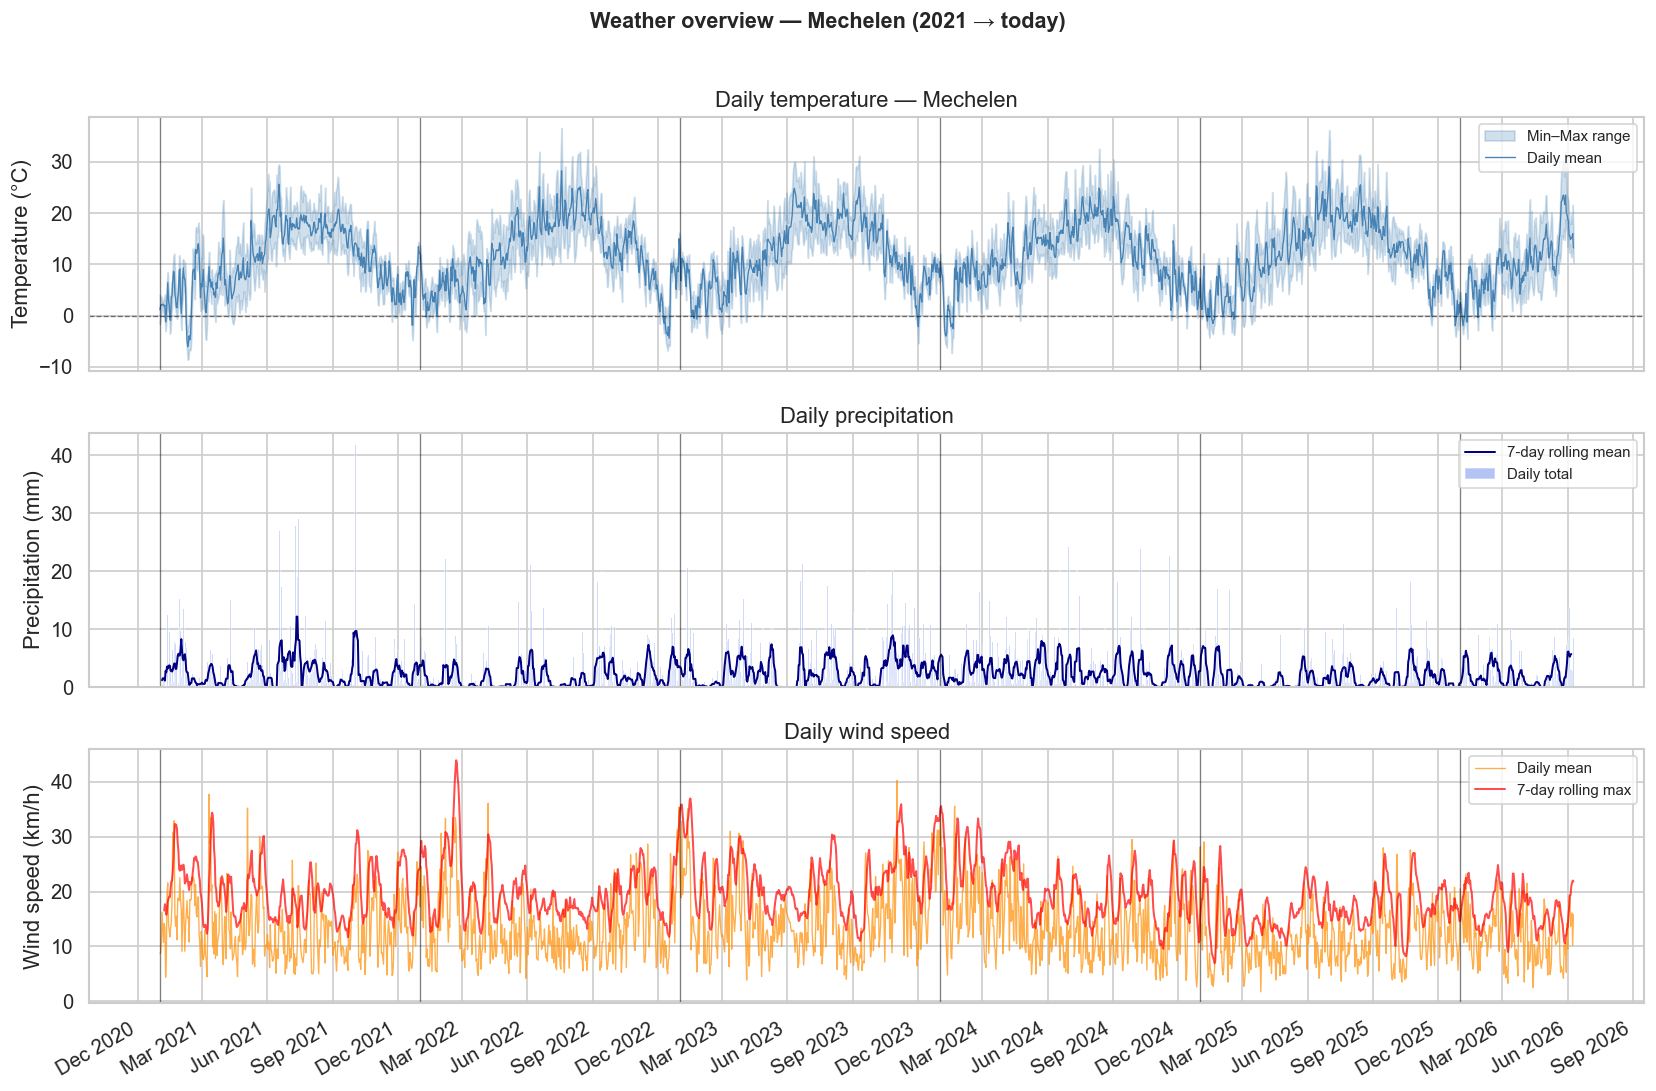

In [4]:
# Daily aggregates for clean time-series plots
df_weather_daily = (
    df_weather.groupby("date").agg(
        temp_mean     = ("temperature_2m",     "mean"),
        temp_min      = ("temperature_2m",     "min"),
        temp_max      = ("temperature_2m",     "max"),
        rain_total    = ("precipitation",      "sum"),
        snow_total    = ("snowfall",           "sum"),
        wind_max      = ("wind_speed_10m",     "max"),
        wind_mean     = ("wind_speed_10m",     "mean"),
        humidity_mean = ("relative_humidity_2m", "mean"),
    )
    .reset_index()
)
df_weather_daily["date"] = pd.to_datetime(df_weather_daily["date"])

jan01 = df_weather_daily["date"][(df_weather_daily["date"].dt.month == 1) & (df_weather_daily["date"].dt.day == 1)]

fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True)

# Temperature band
axes[0].fill_between(df_weather_daily["date"], df_weather_daily["temp_min"], df_weather_daily["temp_max"],
                     alpha=0.25, color="steelblue", label="Min–Max range")
axes[0].plot(df_weather_daily["date"], df_weather_daily["temp_mean"], lw=0.8,
             color="steelblue", label="Daily mean")
axes[0].axhline(0, color="black", lw=0.8, ls="--", alpha=0.5)
for _vline in jan01:
  axes[0].axvline(_vline, color="black", lw=0.8, ls="-", alpha=0.5)
axes[0].set_ylabel("Temperature (°C)")
axes[0].legend(loc="upper right", fontsize=9)
axes[0].set_title("Daily temperature — Mechelen")

# Precipitation
rain_7d = df_weather_daily["rain_total"].rolling(7, center=True).mean()
axes[1].bar(df_weather_daily["date"], df_weather_daily["rain_total"],
            width=1, alpha=0.4, color="royalblue", label="Daily total")
axes[1].plot(df_weather_daily["date"], rain_7d, lw=1.2, color="navy", label="7-day rolling mean")
for _vline in jan01:
  axes[1].axvline(_vline, color="black", lw=0.8, ls="-", alpha=0.5)
axes[1].set_ylabel("Precipitation (mm)")
axes[1].legend(loc="upper right", fontsize=9)
axes[1].set_title("Daily precipitation")

# Wind
axes[2].plot(df_weather_daily["date"], df_weather_daily["wind_mean"],
             lw=0.8, color="darkorange", alpha=0.7, label="Daily mean")
axes[2].plot(df_weather_daily["date"], df_weather_daily["wind_max"].rolling(7).mean(),
             lw=1.2, color="red", alpha=0.7, label="7-day rolling max")
for _vline in jan01:
  axes[2].axvline(_vline, color="black", lw=0.8, ls="-", alpha=0.5)
axes[2].set_ylabel("Wind speed (km/h)")
axes[2].legend(loc="upper right", fontsize=9)
axes[2].set_title("Daily wind speed")
axes[2].xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
axes[2].xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.xticks(rotation=30, ha="right")

fig.suptitle("Weather overview — Mechelen (2021 → today)", fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("data/processed/plot_weather_overview.png", bbox_inches="tight")
plt.show()

### 1a. Weather overview — full time series

### 1b. Commute window weather (06:00 – 09:00) — the hours that matter

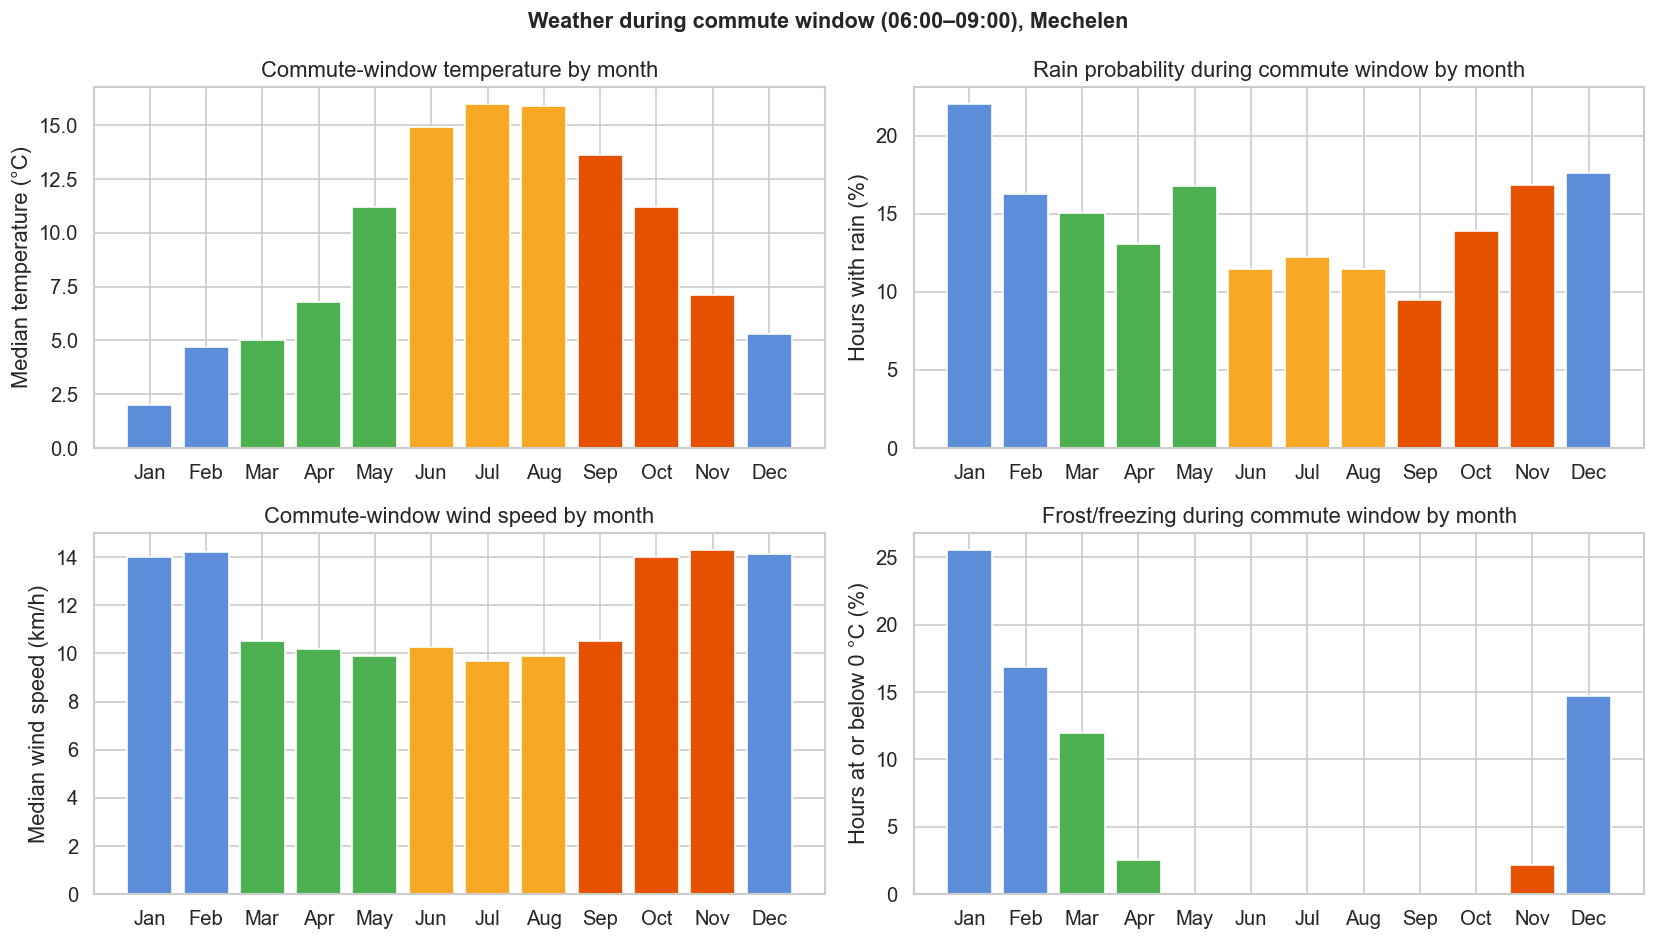

Business insight: Winter and autumn months show the highest rain probability and frost risk during commute hours — key drivers of traffic delays and train disruptions.


In [5]:
# Filter to the commute window hours 06:00–09:00
df_commute_window = df_weather[df_weather["hour"].isin([6, 7, 8, 9])].copy()

# Add month name and season
season_map = {12:"Winter",1:"Winter",2:"Winter",
              3:"Spring",4:"Spring",5:"Spring",
              6:"Summer",7:"Summer",8:"Summer",
              9:"Autumn",10:"Autumn",11:"Autumn"}
df_commute_window["season"] = df_commute_window["month"].map(season_map)
df_commute_window["month_name"] = pd.to_datetime(
    df_commute_window["date"].astype(str)).dt.strftime("%b")

month_order = ["Jan","Feb","Mar","Apr","May","Jun",
               "Jul","Aug","Sep","Oct","Nov","Dec"]

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# Temperature by month
temp_by_month = df_commute_window.groupby("month_name")["temperature_2m"].median().reindex(month_order)
axes[0,0].bar(month_order, temp_by_month.values,
              color=[SEASON_COLORS[season_map[i+1]] for i in range(12)], edgecolor="white")
axes[0,0].axhline(0, color="black", ls="--", lw=0.8)
axes[0,0].set_ylabel("Median temperature (°C)")
axes[0,0].set_title("Commute-window temperature by month")

# Rain probability by month
rain_prob = df_commute_window.groupby("month_name")["precipitation"].apply(
    lambda s: (s > 0).mean()).reindex(month_order)
axes[0,1].bar(month_order, rain_prob.values * 100,
              color=[SEASON_COLORS[season_map[i+1]] for i in range(12)], edgecolor="white")
axes[0,1].set_ylabel("Hours with rain (%)")
axes[0,1].set_title("Rain probability during commute window by month")

# Wind by month
wind_by_month = df_commute_window.groupby("month_name")["wind_speed_10m"].median().reindex(month_order)
axes[1,0].bar(month_order, wind_by_month.values,
              color=[SEASON_COLORS[season_map[i+1]] for i in range(12)], edgecolor="white")
axes[1,0].set_ylabel("Median wind speed (km/h)")
axes[1,0].set_title("Commute-window wind speed by month")

# Snow / frost days
frost = df_commute_window.groupby("month_name")["temperature_2m"].apply(
    lambda s: (s <= 0).mean()).reindex(month_order)
axes[1,1].bar(month_order, frost.values * 100,
              color=[SEASON_COLORS[season_map[i+1]] for i in range(12)], edgecolor="white")
axes[1,1].set_ylabel("Hours at or below 0 °C (%)")
axes[1,1].set_title("Frost/freezing during commute window by month")

for ax in axes.flat:
    ax.tick_params(axis="x", rotation=0)

fig.suptitle("Weather during commute window (06:00–09:00), Mechelen", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("data/processed/plot_commute_window_weather.png", bbox_inches="tight")
plt.show()

print("Business insight: Winter and autumn months show the highest rain probability and frost risk during "
      "commute hours — key drivers of traffic delays and train disruptions.")

### 1c. Weather by weekday — do Mondays have worse weather?

C:\Users\mmylle\AppData\Local\Temp\ipykernel_64432\3058154774.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_cw_wd, x="weekday", y="temperature_2m",
C:\Users\mmylle\AppData\Local\Temp\ipykernel_64432\3058154774.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=rainy, x="weekday", y="precipitation",
C:\Users\mmylle\AppData\Local\Temp\ipykernel_64432\3058154774.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_cw_wd, x="weekday", y="wind_speed_10m",
C:\Users\mmylle\AppData\Local\Temp\ipykernel_64432\3058154774.p

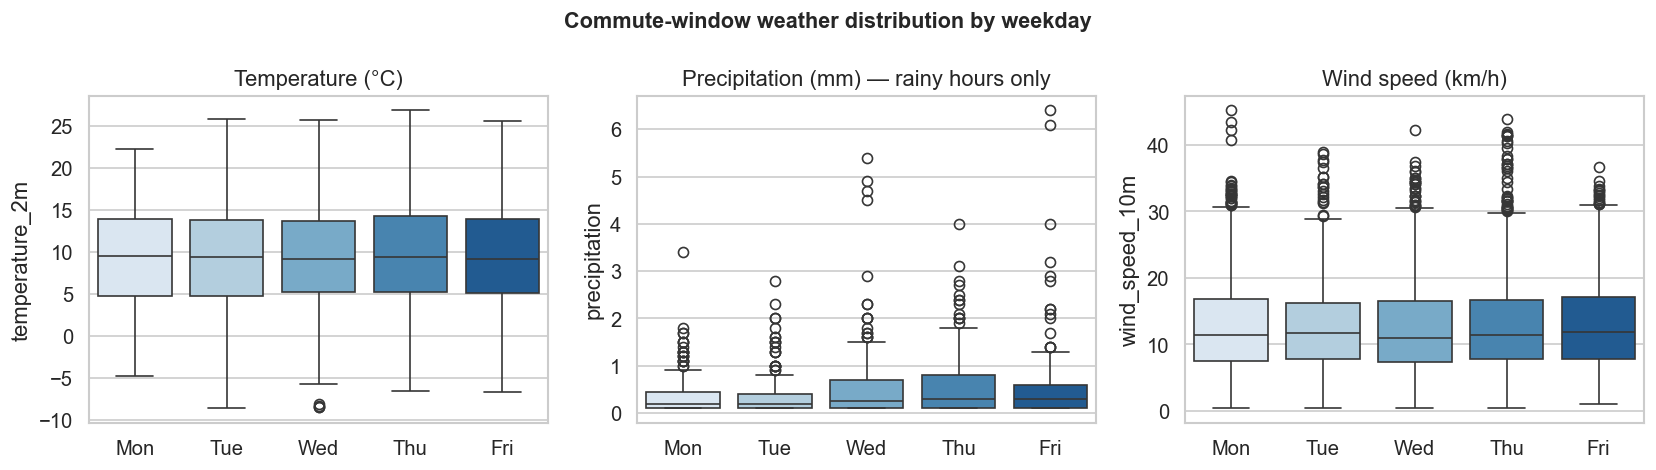

Business insight: Weather distributions are nearly uniform across weekdays — day-of-week traffic patterns are NOT driven by weather alone.


In [6]:
df_cw_wd = df_commute_window[df_commute_window["weekday"].isin(WEEKDAY_ORDER)].copy()

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Temperature
sns.boxplot(data=df_cw_wd, x="weekday", y="temperature_2m",
            order=WEEKDAY_ORDER, ax=axes[0], palette="Blues")
axes[0].set_title("Temperature (°C)")
axes[0].set_xlabel("")

# Precipitation (only rainy hours to avoid zero-inflation)
rainy = df_cw_wd[df_cw_wd["precipitation"] > 0]
sns.boxplot(data=rainy, x="weekday", y="precipitation",
            order=WEEKDAY_ORDER, ax=axes[1], palette="Blues")
axes[1].set_title("Precipitation (mm) — rainy hours only")
axes[1].set_xlabel("")

# Wind speed
sns.boxplot(data=df_cw_wd, x="weekday", y="wind_speed_10m",
            order=WEEKDAY_ORDER, ax=axes[2], palette="Blues")
axes[2].set_title("Wind speed (km/h)")
axes[2].set_xlabel("")

for ax in axes:
    ax.set_xticklabels([d[:3] for d in WEEKDAY_ORDER])

fig.suptitle("Commute-window weather distribution by weekday", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("data/processed/plot_weather_by_weekday.png", bbox_inches="tight")
plt.show()

print("Business insight: Weather distributions are nearly uniform across weekdays — "
      "day-of-week traffic patterns are NOT driven by weather alone.")

---
## 2. Belgian Workdays Calendar

We build a complete calendar (2021 → today + 2 future years) that classifies each day as:
- weekday or weekend
- Belgian public holiday or not
- working day (Mon–Fri, excluding public holidays)
- season, school period indicator (heuristic)

In [7]:
def build_be_calendar(start_year: int = 2021, end_year: int = None) -> pd.DataFrame:
    if end_year is None:
        end_year = date.today().year + 2

    be_hol = holidays.country_holidays("BE", years=range(start_year, end_year + 1))

    dates = pd.date_range(f"{start_year}-01-01", f"{end_year}-12-31", freq="D")
    df = pd.DataFrame({"date": dates})

    df["weekday"]     = df["date"].dt.day_name()
    df["weekday_num"] = df["date"].dt.weekday          # 0=Mon … 4=Fri
    df["month"]       = df["date"].dt.month
    df["year"]        = df["date"].dt.year
    df["iso_week"]    = df["date"].dt.isocalendar().week.astype(int)

    df["is_weekend"]  = df["weekday_num"] >= 5
    df["is_holiday"]  = df["date"].dt.date.astype("O").isin(be_hol)
    df["holiday_name"] = df["date"].dt.date.astype("O").map(lambda d: be_hol.get(d, ""))
    df["is_workday"]  = ~df["is_weekend"] & ~df["is_holiday"]

    season_map = {12:"Winter",1:"Winter",2:"Winter",
                  3:"Spring",4:"Spring",5:"Spring",
                  6:"Summer",7:"Summer",8:"Summer",
                  9:"Autumn",10:"Autumn",11:"Autumn"}
    df["season"] = df["month"].map(season_map)

    # Heuristic Belgian school periods (July + August = school holidays)
    df["is_school_holiday"] = df["month"].isin([7, 8])

    return df


calendar_path = RAW / "calendar_be.csv"
df_calendar = build_be_calendar()
df_calendar.to_csv(calendar_path, index=False)

hist_workdays = df_calendar[
    df_calendar["is_workday"] & (df_calendar["date"].dt.date <= date.today())
]
print(f"Calendar: {len(df_calendar):,} days total")
print(f"Historical workdays (up to today): {len(hist_workdays):,}")
print(f"Public holidays per year:")
print(df_calendar[df_calendar["is_holiday"]].groupby("year").size().to_string())
df_calendar.head(10)

Calendar: 2,922 days total
Historical workdays (up to today): 1,381
Public holidays per year:
year
2021    12
2022    12
2023    12
2024    12
2025    12
2026    12
2027    12
2028    12


,date,weekday,weekday_num,month,year,iso_week,is_weekend,is_holiday,holiday_name,is_workday,season,is_school_holiday
0,2021-01-01,Friday,4,1,2021,53,False,True,Nieuwjaar,False,Winter,False
1,2021-01-02,Saturday,5,1,2021,53,True,False,,False,Winter,False
2,2021-01-03,Sunday,6,1,2021,53,True,False,,False,Winter,False
3,2021-01-04,Monday,0,1,2021,1,False,False,,True,Winter,False
4,2021-01-05,Tuesday,1,1,2021,1,False,False,,True,Winter,False
5,2021-01-06,Wednesday,2,1,2021,1,False,False,,True,Winter,False
6,2021-01-07,Thursday,3,1,2021,1,False,False,,True,Winter,False
7,2021-01-08,Friday,4,1,2021,1,False,False,,True,Winter,False
8,2021-01-09,Saturday,5,1,2021,1,True,False,,False,Winter,False
9,2021-01-10,Sunday,6,1,2021,1,True,False,,False,Winter,False


### 2a. Calendar EDA

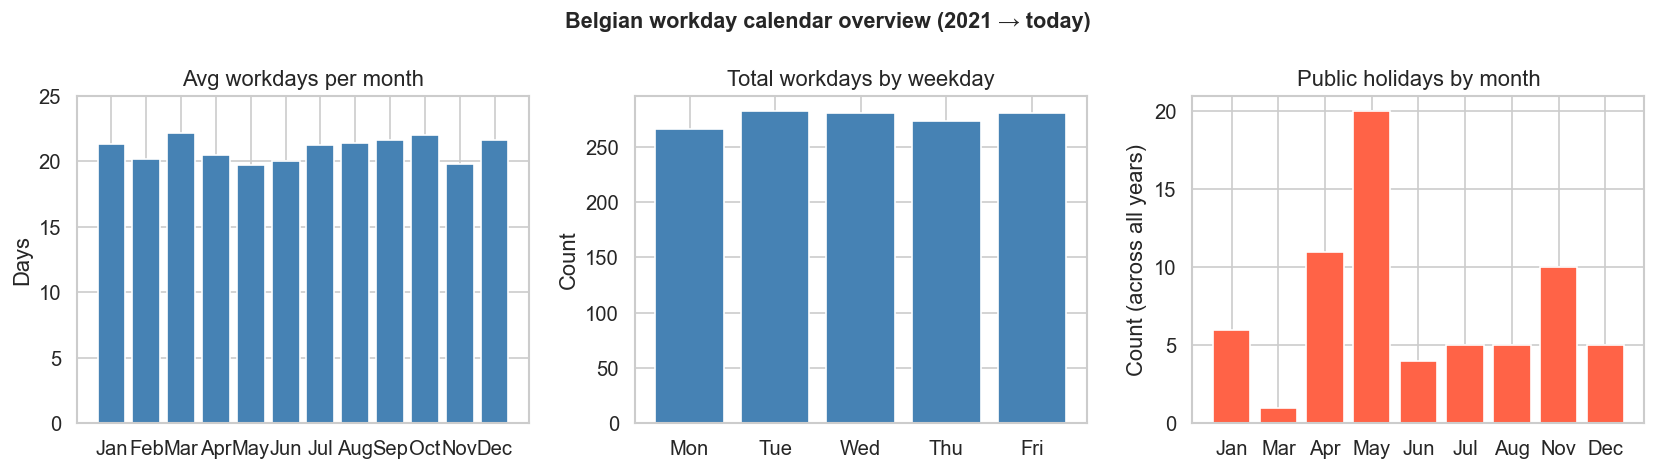

Business insight: May and November have the most public holidays, reducing office attendance and making those months lighter on commute pressure.


In [8]:
hist_cal = df_calendar[
    (df_calendar["date"].dt.year >= 2021) &
    (df_calendar["date"].dt.date <= date.today())
].copy()

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Workdays per month
workdays_per_month = (
    hist_cal[hist_cal["is_workday"]]
    .groupby(["year", "month"])
    .size()
    .reset_index(name="n")
)
workdays_per_month["ym"] = workdays_per_month["year"].astype(str) + "-" + workdays_per_month["month"].astype(str).str.zfill(2)
workdays_per_month = workdays_per_month.sort_values("ym")
avg_per_month = workdays_per_month.groupby("month")["n"].mean()
month_names = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]
axes[0].bar(month_names, avg_per_month.values, color="steelblue", edgecolor="white")
axes[0].set_title("Avg workdays per month")
axes[0].set_ylabel("Days")
axes[0].set_ylim(0, 25)

# Workdays per weekday
wd_counts = hist_cal[hist_cal["is_workday"]]["weekday"].value_counts().reindex(WEEKDAY_ORDER)
axes[1].bar([d[:3] for d in WEEKDAY_ORDER], wd_counts.values, color="steelblue", edgecolor="white")
axes[1].set_title("Total workdays by weekday")
axes[1].set_ylabel("Count")

# Holidays by month
hol_per_month = hist_cal[hist_cal["is_holiday"]]["month"].value_counts().sort_index()
axes[2].bar([month_names[m-1] for m in hol_per_month.index], hol_per_month.values,
            color="tomato", edgecolor="white")
axes[2].set_title("Public holidays by month")
axes[2].set_ylabel("Count (across all years)")

fig.suptitle("Belgian workday calendar overview (2021 → today)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("data/processed/plot_calendar_overview.png", bbox_inches="tight")
plt.show()

print("Business insight: May and November have the most public holidays, reducing office "
      "attendance and making those months lighter on commute pressure.")

---
## 3. Real Train Data — Infrabel Punctuality History

Instead of the iRail schedule approximation, we now use **real Infrabel data**: 
the official per-stop punctuality records published by Infrabel (Belgian rail 
infrastructure manager).

The index file `data/newdata/newtraindatasets.csv` lists 148 monthly CSV files 
(2014–2026). We download months from **2021 onwards**, filter to trains departing 
**Gent-Sint-Pieters** between 06:00–09:00, join with **Mechelen** arrivals on the 
same train, and aggregate to daily stats.

| Column | Meaning |
|---|---|
| `train_planned_journey_min` | Median scheduled journey time (timetable) |
| `train_actual_journey_min`  | Median real journey time including delays |
| `train_delay_arr_median_s`  | Median arrival delay at Mechelen (seconds) |
| `train_on_time_pct`         | Share of trains arriving ≤ 5 min late |
| `train_cancelled_pct`       | Share of trains scheduled to serve Mechelen that never arrived |

**Cancellation detection**: a train is counted as cancelled if it was *scheduled* 
to stop at Mechelen (`planned_arr` is not NaN) but never arrived there (`real_arr` 
is NaN). This covers both trains cancelled at Gent and trains cancelled en route. 
Trains whose route does not include Mechelen at all are excluded from the count.

**Note — `FORCE_REFRESH`**: set it to `True` in the cell below the first time you 
run after clearing the Infrabel caches, or whenever you want to reprocess from scratch.
The raw files are ~300 MB each; with 4 parallel workers the full download takes 
roughly ¼ of the sequential time. Once the caches are warm, subsequent runs are instant.

In [9]:
# ── Refresh control ───────────────────────────────────────────────────────────
# Set FORCE_REFRESH = True to delete all caches and re-download + reprocess
# every Infrabel monthly file.  Leave False for fast cached loading.
FORCE_REFRESH = False

import sys, os
sys.path.insert(0, os.getcwd())
from data_pipeline import fetch_infrabel_punctuality, CAR_PREF_BUFFER_MIN

if FORCE_REFRESH:
    import pathlib
    for f in pathlib.Path("data/raw/infrabel").glob("*.csv"):
        f.unlink()
    cached_combined = pathlib.Path("data/processed/infrabel_daily_commute.csv")
    if cached_combined.exists():
        cached_combined.unlink()
    print("Infrabel caches cleared — will re-download all monthly files.")

df_infrabel = fetch_infrabel_punctuality(force_refresh=FORCE_REFRESH)

if df_infrabel.empty:
    print("No Infrabel data loaded — check the index file path.")
else:
    print(f"Shape: {df_infrabel.shape}")
    print(f"Date range: {df_infrabel['date'].min().date()} -> {df_infrabel['date'].max().date()}")
    missing = df_infrabel.isnull().sum()
    missing = missing[missing > 0]
    print(f"\nMissing values:\n{missing.to_string() if len(missing) else 'None'}")
    print(f"\nOverall cancellation rate : {df_infrabel['train_cancelled_pct'].mean():.2%}")
    print(f"Overall on-time rate      : {df_infrabel['train_on_time_pct'].mean():.2%}")
    display(df_infrabel.head(10))

[factors] Loaded calibrated factors from factors.json  (calibrated on 2026-06-16)
[train_real] Loading Infrabel data from cache: data\processed\infrabel_daily_commute.csv
[train_real] 1,758 days with real train data loaded.
Shape: (1758, 7)
Date range: 2021-01-01 -> 2026-04-30

Missing values:
train_planned_journey_min    4
train_actual_journey_min     4

Overall cancellation rate : 0.00%
Overall on-time rate      : 86.95%


,date,n_trains,train_planned_journey_min,train_actual_journey_min,train_delay_arr_median_s,train_on_time_pct,train_cancelled_pct
0,2021-01-01,2,54.0,54.225000,3.0,1.000000,0.0
1,2021-01-02,2,54.0,53.458333,-33.0,1.000000,0.0
2,2021-01-03,2,54.0,54.008333,-17.0,1.000000,0.0
3,2021-01-04,6,58.0,57.541667,94.5,0.833333,0.0
4,2021-01-05,6,58.0,63.625000,50.5,0.833333,0.0
5,2021-01-06,6,58.0,57.050000,-35.5,1.000000,0.0
6,2021-01-07,6,58.0,58.791667,53.0,0.833333,0.0
7,2021-01-08,6,58.0,57.183333,0.5,1.000000,0.0
8,2021-01-09,8,37.0,38.683333,167.5,0.750000,0.0
9,2021-01-10,8,37.0,39.108333,98.0,0.875000,0.0


### 3a. Delay distribution and monthly on-time rate

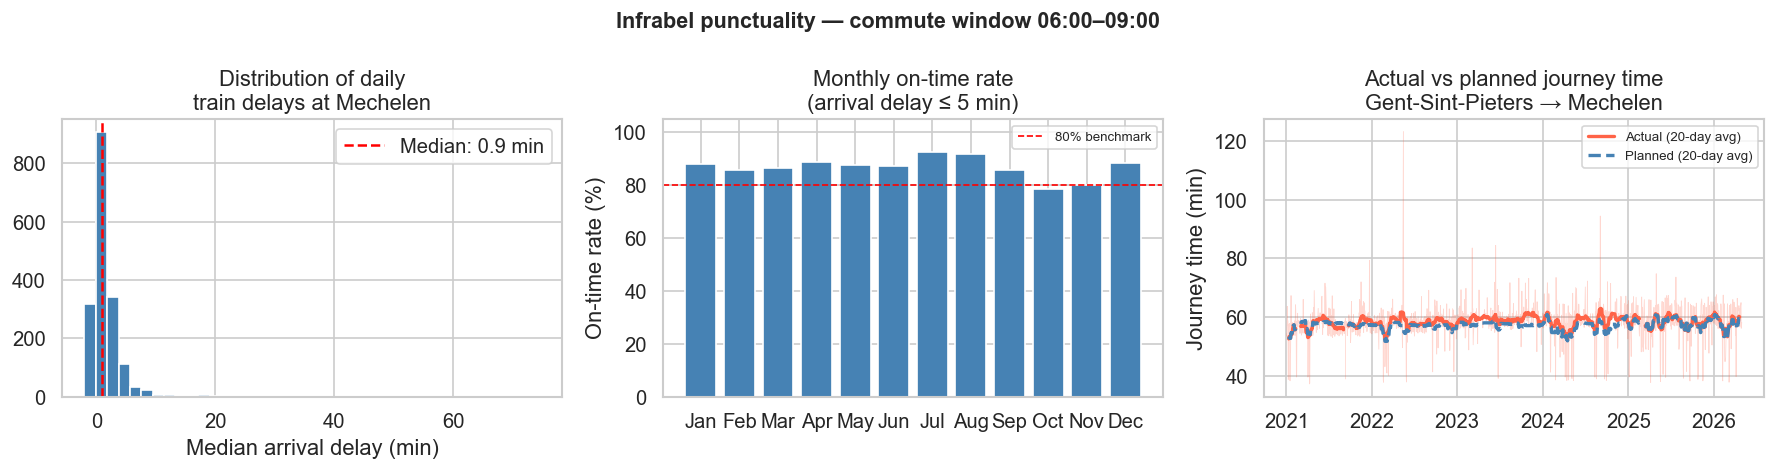

Days with median delay > 5 min : 5.7%
Overall average on-time rate   : 86.9%
Overall cancellation rate      : 0.0%


In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

if not df_infrabel.empty:
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    # Delay histogram
    delay_min = df_infrabel["train_delay_arr_median_s"].dropna() / 60
    axes[0].hist(delay_min, bins=40, color="steelblue", edgecolor="white")
    axes[0].axvline(delay_min.median(), color="red", ls="--", lw=1.5,
                    label=f"Median: {delay_min.median():.1f} min")
    axes[0].set_xlabel("Median arrival delay (min)")
    axes[0].set_title("Distribution of daily\ntrain delays at Mechelen")
    axes[0].legend()

    # On-time rate by calendar month
    df_infrabel["month"] = pd.to_datetime(df_infrabel["date"]).dt.month
    month_ot = df_infrabel.groupby("month")["train_on_time_pct"].mean()
    month_names = ["Jan","Feb","Mar","Apr","May","Jun",
                   "Jul","Aug","Sep","Oct","Nov","Dec"]
    axes[1].bar([month_names[m-1] for m in month_ot.index],
                month_ot.values * 100, color="steelblue", edgecolor="white")
    axes[1].axhline(80, color="red", ls="--", lw=1, label="80% benchmark")
    axes[1].set_ylabel("On-time rate (%)")
    axes[1].set_title("Monthly on-time rate\n(arrival delay ≤ 5 min)")
    axes[1].set_ylim(0, 105)
    axes[1].legend(fontsize=8)

    # Actual vs planned journey time rolling average
    df_infrabel["date_dt"] = pd.to_datetime(df_infrabel["date"])
    df_sorted = df_infrabel.sort_values("date_dt")
    axes[2].plot(df_sorted["date_dt"], df_sorted["train_actual_journey_min"],
                 alpha=0.25, lw=0.5, color="tomato")
    axes[2].plot(df_sorted["date_dt"],
                 df_sorted["train_actual_journey_min"].rolling(20, center=True).mean(),
                 lw=2, color="tomato", label="Actual (20-day avg)")
    axes[2].plot(df_sorted["date_dt"],
                 df_sorted["train_planned_journey_min"].rolling(20, center=True).mean(),
                 lw=2, color="steelblue", ls="--", label="Planned (20-day avg)")
    axes[2].set_ylabel("Journey time (min)")
    axes[2].set_title("Actual vs planned journey time\nGent-Sint-Pieters → Mechelen")
    axes[2].legend(fontsize=8)

    fig.suptitle("Infrabel punctuality — commute window 06:00–09:00",
                 fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.savefig("data/processed/plot_infrabel_overview.png", bbox_inches="tight")
    plt.show()

    pct_late = (df_infrabel["train_delay_arr_median_s"] > 300).mean()
    print(f"Days with median delay > 5 min : {pct_late:.1%}")
    print(f"Overall average on-time rate   : {df_infrabel['train_on_time_pct'].mean():.1%}")
    print(f"Overall cancellation rate      : {df_infrabel['train_cancelled_pct'].mean():.1%}")


### 3b. Delay by weekday — are some days worse for trains?

C:\Users\mmylle\AppData\Local\Temp\ipykernel_64432\3759214836.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_wd, x="weekday", y="delay_min",
C:\Users\mmylle\AppData\Local\Temp\ipykernel_64432\3759214836.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels([d[:3] for d in WEEKDAY_ORDER])


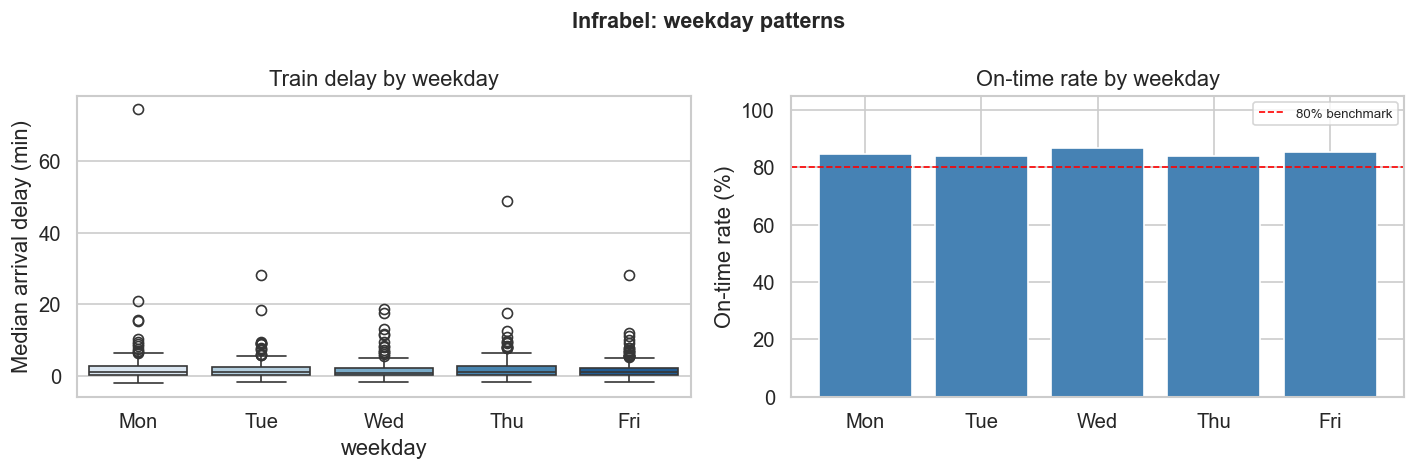

Insight: peak demand days (Tue/Thu) tend to show higher delays,
mirroring the car congestion pattern — both modes are stressed simultaneously.


In [11]:
if not df_infrabel.empty:
    WEEKDAY_ORDER = ["Monday","Tuesday","Wednesday","Thursday","Friday"]
    df_infrabel["weekday"] = pd.to_datetime(df_infrabel["date"]).dt.day_name()
    df_wd = df_infrabel[df_infrabel["weekday"].isin(WEEKDAY_ORDER)].copy()
    df_wd["delay_min"] = df_wd["train_delay_arr_median_s"] / 60

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    sns.boxplot(data=df_wd, x="weekday", y="delay_min",
                order=WEEKDAY_ORDER, ax=axes[0], palette="Blues")
    axes[0].set_xticklabels([d[:3] for d in WEEKDAY_ORDER])
    axes[0].set_ylabel("Median arrival delay (min)")
    axes[0].set_title("Train delay by weekday")

    ot_wd = df_wd.groupby("weekday")["train_on_time_pct"].mean().reindex(WEEKDAY_ORDER)
    axes[1].bar([d[:3] for d in WEEKDAY_ORDER],
                ot_wd.values * 100, color="steelblue", edgecolor="white")
    axes[1].axhline(80, color="red", ls="--", lw=1, label="80% benchmark")
    axes[1].set_ylabel("On-time rate (%)")
    axes[1].set_title("On-time rate by weekday")
    axes[1].set_ylim(0, 105)
    axes[1].legend(fontsize=8)

    fig.suptitle("Infrabel: weekday patterns", fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.savefig("data/processed/plot_infrabel_by_weekday.png", bbox_inches="tight")
    plt.show()
    print("Insight: peak demand days (Tue/Thu) tend to show higher delays,")
    print("mirroring the car congestion pattern — both modes are stressed simultaneously.")


---
## 4a. Car Route Baseline — OSRM

OSRM (Open Source Routing Machine) is a free routing engine based on OpenStreetMap. The public demo server requires no API key. It gives us:
- **Base (free-flow) travel time**: the theoretical minimum assuming no congestion
- **Route distance** in km

From the base time we derive **congestion-adjusted estimates** using published traffic research for Belgian highways:
- Monday and Tuesday/Thursday peaks add 15–25% to free-flow time during morning rush
- Rain adds ~5–8%, heavy rain ~12%, snow or ice ~20–30%
- These factors come from TomTom Traffic Index and Flemish traffic research (AWV).

We then build a **daily travel time estimate** combining the OSRM base time with weather + weekday factors.

In [12]:
def fetch_osrm_route(lon1: float, lat1: float, lon2: float, lat2: float) -> dict:
    """Get route info from OSRM public demo server (no API key required)."""
    coords = f"{lon1},{lat1};{lon2},{lat2}"
    url = f"https://router.project-osrm.org/route/v1/driving/{coords}"
    params = {"overview": "false", "annotations": "false"}
    r = requests.get(url, params=params, timeout=30)
    r.raise_for_status()
    route = r.json()["routes"][0]
    return {
        "distance_km":       round(route["distance"] / 1000, 2),
        "free_flow_min":     round(route["duration"] / 60, 1),
    }


route_cache = RAW / "osrm_route_gent_mechelen.json"

if route_cache.exists():
    with open(route_cache) as f:
        route_info = json.load(f)
    print("Loaded route from cache.")
else:
    print("Fetching route from OSRM...")
    route_info = fetch_osrm_route(LON_GENT, LAT_GENT, LON_MECHELEN, LAT_MECHELEN)
    with open(route_cache, "w") as f:
        json.dump(route_info, f)
    print("Saved to cache.")

FREE_FLOW_MIN  = route_info["free_flow_min"]
ROUTE_KM       = route_info["distance_km"]
print(f"\nGent-Sint-Pieters → Mechelen (via E40/R4):")
print(f"  Distance   : {ROUTE_KM} km")
print(f"  Free-flow  : {FREE_FLOW_MIN} min  (OSRM, no traffic)")
print(f"  Typical rush: ~{FREE_FLOW_MIN * 1.25:.0f}–{FREE_FLOW_MIN * 1.50:.0f} min (Tue/Thu morning peak)")

Loaded route from cache.

Gent-Sint-Pieters → Mechelen (via E40/R4):
  Distance   : 78.45 km
  Free-flow  : 59.5 min  (OSRM, no traffic)
  Typical rush: ~74–89 min (Tue/Thu morning peak)


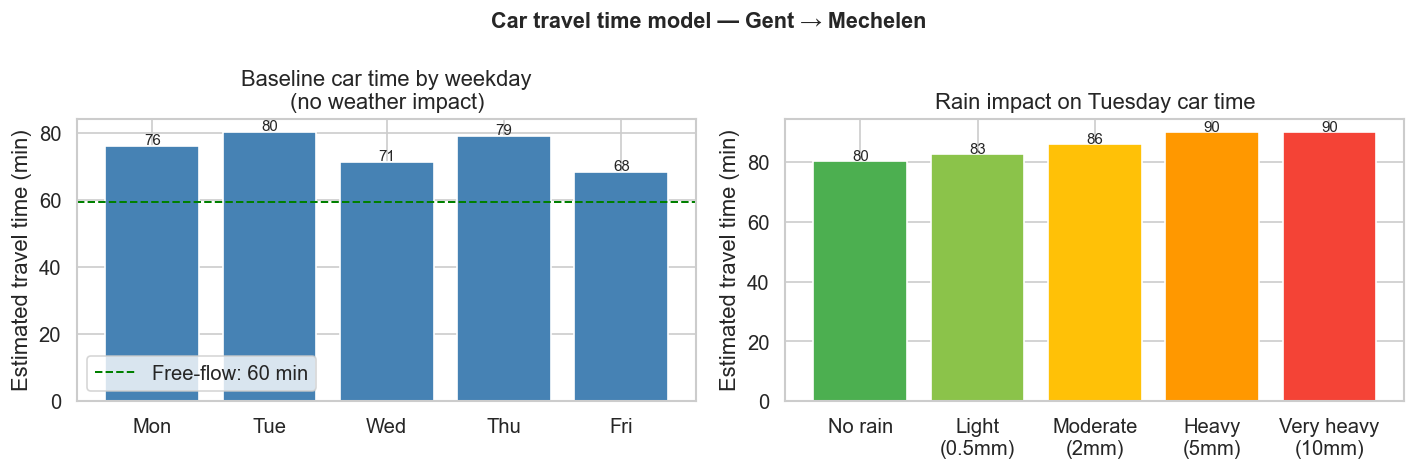

Free-flow baseline: 60 min
Worst case (heavy rain + Tue): 90 min
Best case (Fri, no rain): 68 min


In [13]:
# Build congestion multiplier table based on day-of-week and weather
# Sources: TomTom Traffic Index Belgium 2022-2024, AWV verkeersstudies

# Weekday congestion multipliers for 07:00-09:00 rush on the E40 corridor
WEEKDAY_CONGESTION = {
    "Monday":    1.28,   # post-weekend traffic build-up
    "Tuesday":   1.35,   # peak rush day
    "Wednesday": 1.20,
    "Thursday":  1.33,   # near peak
    "Friday":    1.15,   # lighter morning, heavier evening
}

def car_travel_time(row) -> float:
    """Estimate car travel time (min) from OSRM baseline + weather + weekday factors."""
    base = FREE_FLOW_MIN
    wd_mult = WEEKDAY_CONGESTION.get(row.get("weekday", "Wednesday"), 1.20)

    # Weather factors
    rain = row.get("rain_peak", 0) or 0
    wind = row.get("wind_peak", 0) or 0
    temp_min = row.get("temp_min", 10) or 10
    snow = row.get("snow_total", 0) or 0

    weather_mult = 1.0
    if rain >= 5:    weather_mult += 0.12
    elif rain >= 2:  weather_mult += 0.07
    elif rain >= 0.5: weather_mult += 0.03

    if snow >= 1:    weather_mult += 0.25
    if temp_min <= -3: weather_mult += 0.15
    elif temp_min <= 0: weather_mult += 0.07

    if wind >= 60:   weather_mult += 0.08
    elif wind >= 45: weather_mult += 0.04

    return round(base * wd_mult * weather_mult, 1)


# Visualize the congestion + weather sensitivity
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Weekday sensitivity
wd_times = {wd: round(FREE_FLOW_MIN * mult, 1) for wd, mult in WEEKDAY_CONGESTION.items()}
axes[0].bar([d[:3] for d in WEEKDAY_ORDER],
            [wd_times[d] for d in WEEKDAY_ORDER],
            color="steelblue", edgecolor="white")
axes[0].axhline(FREE_FLOW_MIN, color="green", ls="--", lw=1.2, label=f"Free-flow: {FREE_FLOW_MIN:.0f} min")
axes[0].set_ylabel("Estimated travel time (min)")
axes[0].set_title("Baseline car time by weekday\n(no weather impact)")
axes[0].legend()
for i, (wd, t) in enumerate([(d, wd_times[d]) for d in WEEKDAY_ORDER]):
    axes[0].text(i, t + 0.5, f"{t:.0f}", ha="center", fontsize=9)

# Weather sensitivity (for a typical Tuesday)
rain_vals  = [0, 0.5, 2, 5, 10]
base_tue   = FREE_FLOW_MIN * WEEKDAY_CONGESTION["Tuesday"]
rain_times = []
for r in rain_vals:
    mult = 1.0
    if r >= 5:    mult += 0.12
    elif r >= 2:  mult += 0.07
    elif r >= 0.5: mult += 0.03
    rain_times.append(round(base_tue * mult, 1))

labels = ["No rain", "Light\n(0.5mm)", "Moderate\n(2mm)", "Heavy\n(5mm)", "Very heavy\n(10mm)"]
bars = axes[1].bar(labels, rain_times, color=["#4caf50","#8bc34a","#ffc107","#ff9800","#f44336"], edgecolor="white")
axes[1].set_ylabel("Estimated travel time (min)")
axes[1].set_title("Rain impact on Tuesday car time")
for bar, t in zip(bars, rain_times):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 f"{t:.0f}", ha="center", fontsize=9)

fig.suptitle("Car travel time model — Gent → Mechelen", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("data/processed/plot_car_travel_model.png", bbox_inches="tight")
plt.show()

print(f"Free-flow baseline: {FREE_FLOW_MIN:.0f} min")
print(f"Worst case (heavy rain + Tue): {round(FREE_FLOW_MIN * 1.35 * 1.12, 0):.0f} min")
print(f"Best case (Fri, no rain): {round(FREE_FLOW_MIN * 1.15, 0):.0f} min")

## 4b. Car Travel Times — Vlaams Verkeercentrum (primary source)

Real measured travel times for the **E17 → R1 → E19 via Antwerpen** route, published by the [Flemish Traffic Centre](https://indicatoren.verkeerscentrum.be/).

**Why prefer this over OSRM?**
- OSRM gives free-flow time for an *assumed* route — it cannot capture real congestion.
- VC data is *measured* from actual traffic sensors (Mon–Fri school days only).
- Coverage: Jan 2021 → present, except **July & August** (school holidays, no school-day data).

**Route segments used (Gent → Mechelen):**

| # | Highway | Direction |
|---|---------|-----------|
| 1 | A14 / E17 | Gent → Antwerpen |
| 2 | R1 buitenring | Antwerpen ring (Linkeroever → Antwerpen-Zuid) |
| 3 | A1 / E19 | Antwerpen → Mechelen-Noord |

**`vc_car_base_min`** = sum of all segment times for a given 5-min slot, averaged over the commute window 06:00–09:55.
Weekday deviations and weather factors are applied on top by `data_pipeline.py`.

Traffic indicators are available from the ['Vlaams Verkeercentrum'](https://indicatoren.verkeerscentrum.be/vc.indicators.web.gui/indicator/index#) website. The time to travel ('reistijd') from Gent to Mechelen is downloaded in the website directly:  
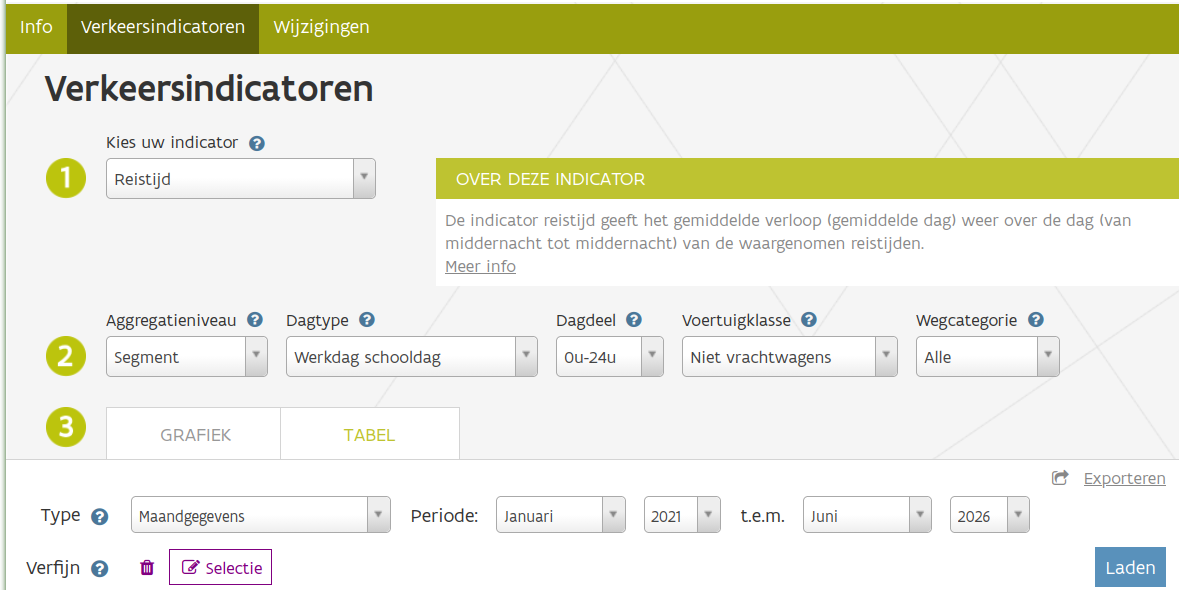
Note: The road segments annotations are described in the [Info](https://indicatoren.verkeerscentrum.be/vc.indicators.web.gui/indicator/index) page of the website.  
One drawback of this dataset is that the data is aggregated over all days of the week (Monday to Friday school days).

The following highways/crosspoints ('Knop') are used, resulting in the selection of the following road segments: 
1. from Gent to Antwerpen: E17 (A14):
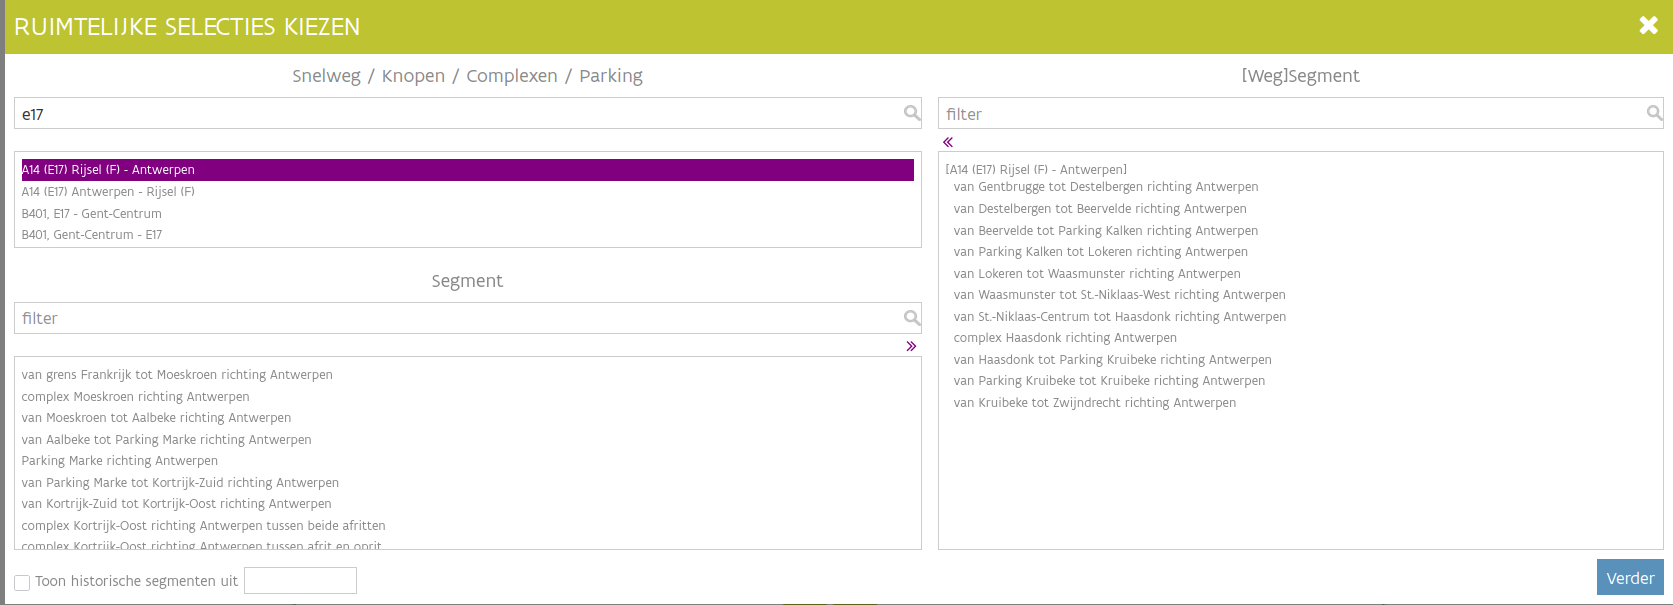
3. Ring of Antwerpen (R1): from Antwerpen-West (AW) to Antwerpen-Zuid (ANZ)
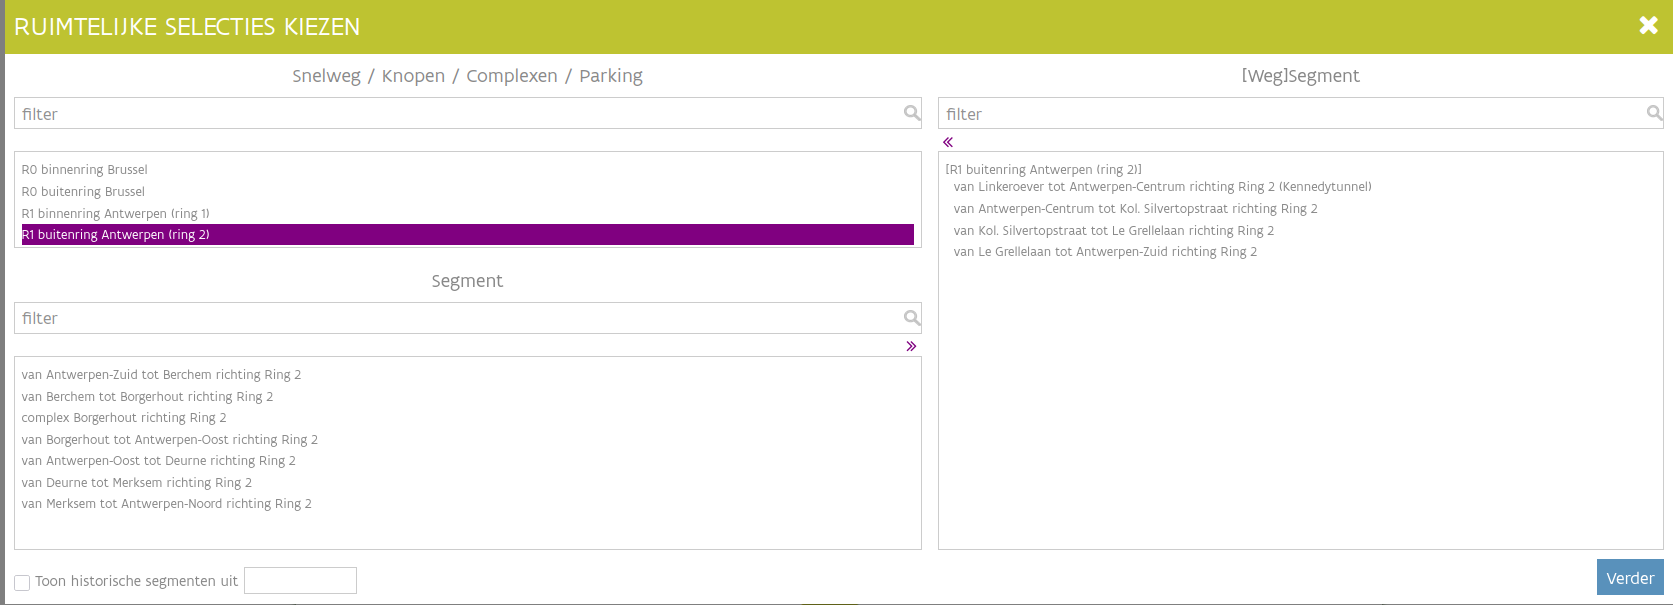
5. from Antwerpen to Mechelen: E19
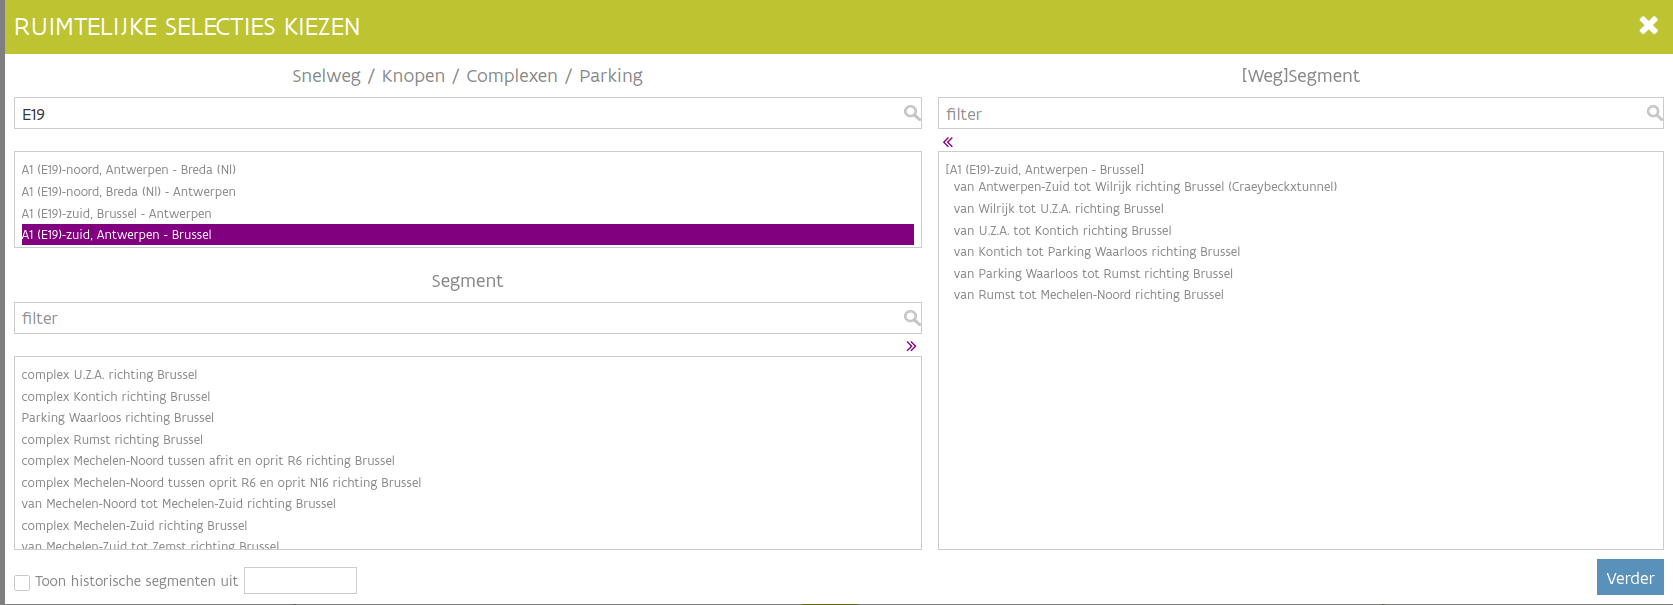

(The data is extracted in multiple times to avoid the error: `504 Gateway Time-out`.)

In [14]:
dir = './data/raw/'
import os
data_traffic_list = []
for file in os.listdir(dir):
    if file.startswith("reistijd"):
        # print(file)
        data_traffic = pd.read_excel(io = os.path.join(dir, file), sheet_name = 'data')
        data_traffic_list.append(data_traffic)
data_traffic = pd.concat(data_traffic_list)

c:\Users\mmylle\AppData\Local\anaconda3\Lib\site-packages\openpyxl\styles\stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")
c:\Users\mmylle\AppData\Local\anaconda3\Lib\site-packages\openpyxl\styles\stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")
c:\Users\mmylle\AppData\Local\anaconda3\Lib\site-packages\openpyxl\styles\stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")
c:\Users\mmylle\AppData\Local\anaconda3\Lib\site-packages\openpyxl\styles\stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")
c:\Users\mmylle\AppData\Local\anaconda3\Lib\site

In [15]:
data_traffic.head(1)

,jaar,maand,omschrijving,segmentnaam,tijdstip,gem_reistijd_auto
0,2024,1,A14 (E17) Rijsel (F) - Antwerpen,van Gentbrugge tot Destelbergen richting Antwe...,09:30,2.73


In [16]:
# extract hour
data_traffic['tijdstip_hour'] = data_traffic['tijdstip'].str.extract(r"(\d{2})")
data_traffic['tijdstip_hour'] = pd.to_numeric(data_traffic['tijdstip_hour'])

# filter data for peak hours: 6h -> 9h
data_traffic = data_traffic.loc[data_traffic['tijdstip_hour'].isin([6, 7, 8, 9])]

In [17]:
# sum travelling time across all segments
data_traffic_agg = data_traffic.groupby(['jaar', 'maand', 'omschrijving', 'tijdstip', 'tijdstip_hour'])['gem_reistijd_auto'].sum().reset_index()

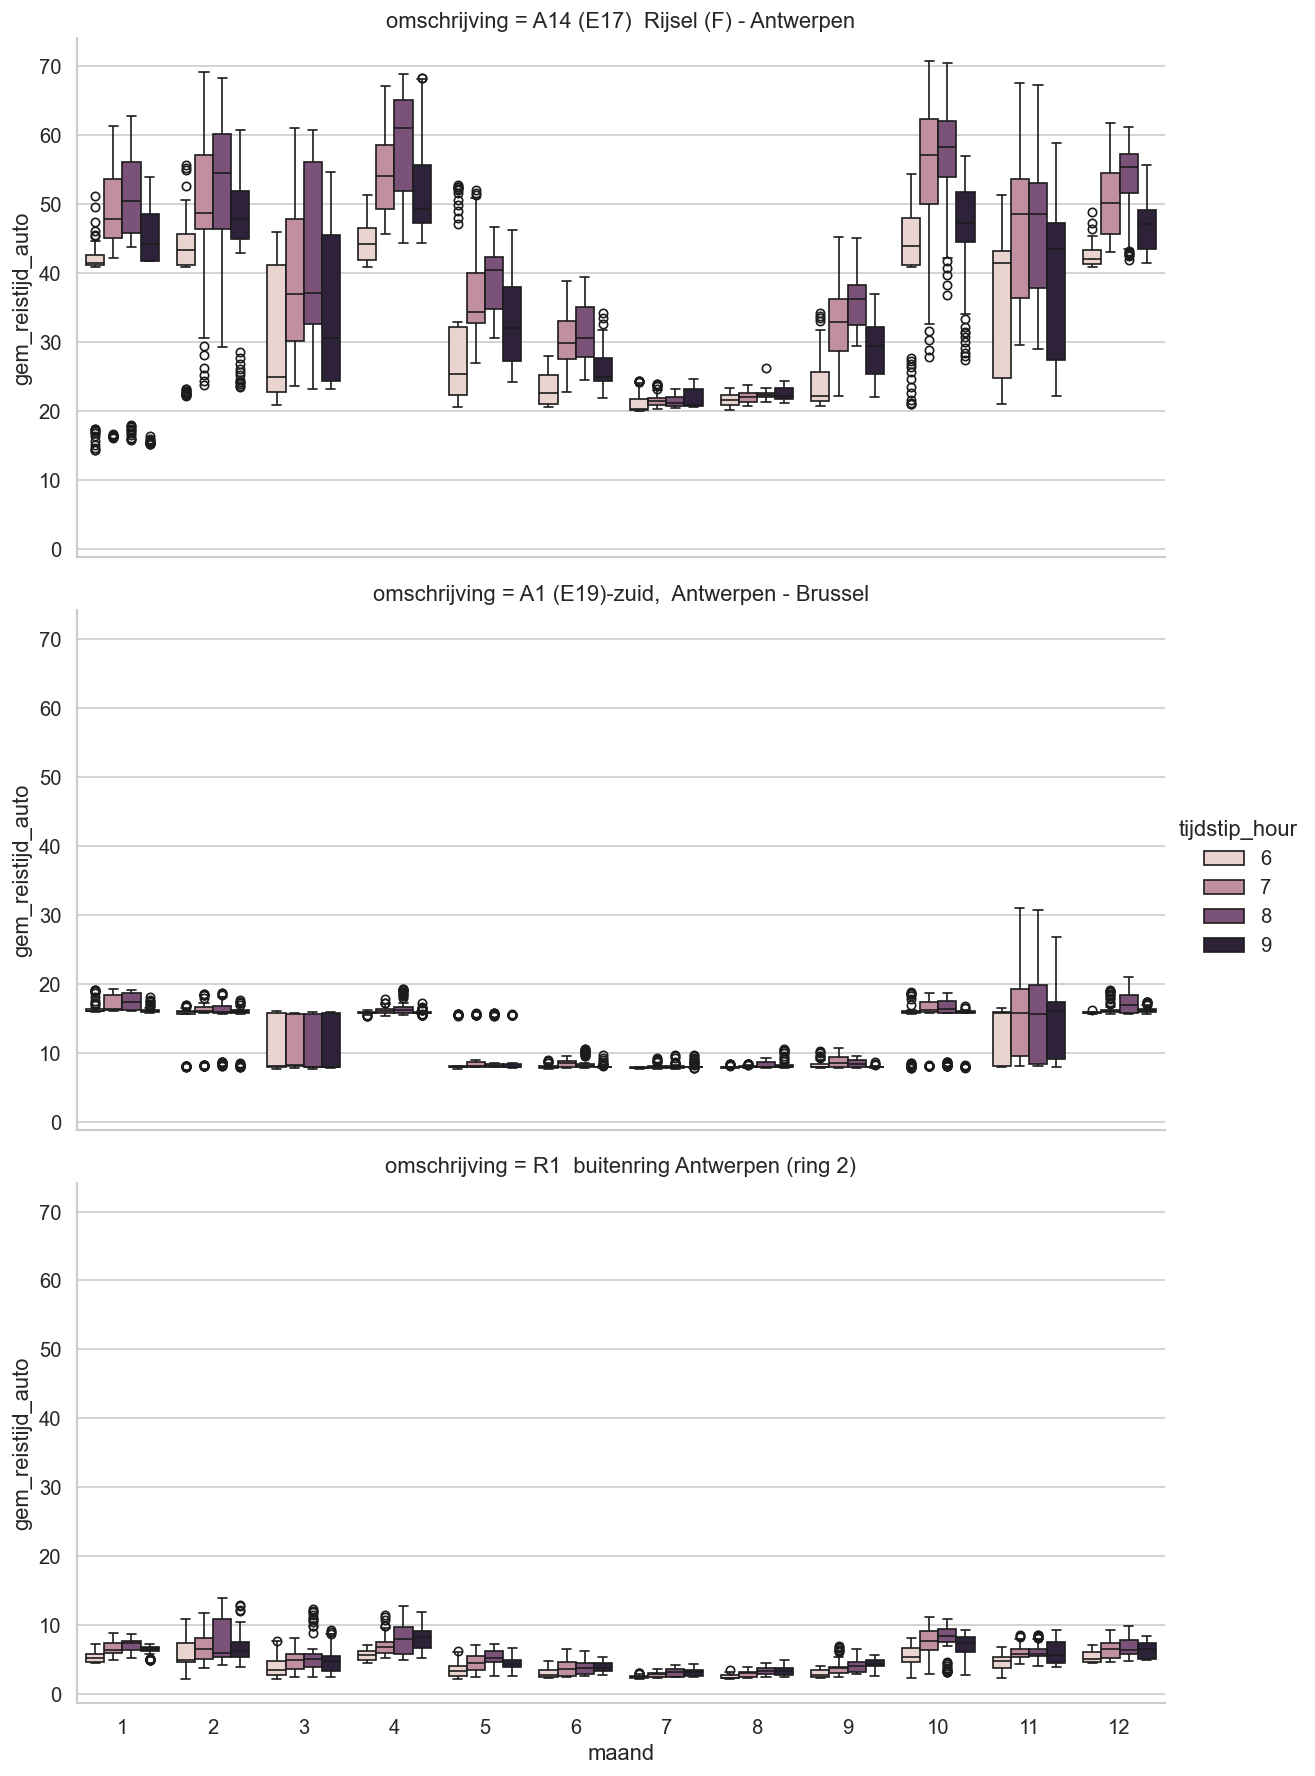

In [18]:
sns.catplot(
    data = data_traffic_agg, x = 'maand', y = 'gem_reistijd_auto', hue = 'tijdstip_hour',
    row = "omschrijving", kind = 'box', height = 5, aspect = 2
)
#sns.boxplot(data = data_traffic_agg, x = 'maand', y = 'gem_reistijd_auto', hue = 'omschrijving', ax = ax)

[car_vc] Loading VC travel times from cache: data\processed\vc_travel_times.csv
VC travel time data: 54 month-entries
Years covered      : [np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025), np.int64(2026)]
Months covered     : [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(9), np.int64(10), np.int64(11), np.int64(12)]  (7 & 8 = school holidays, absent)

VC base time stats (min):
  Mean   : 41.3 min
  Median : 42.6 min
  Min    : 16.2 min
  Max    : 48.1 min

Relative weekday multipliers (applied on top of VC base):
  Monday      : 1.116  (slower than Mon–Fri avg)
  Tuesday     : 0.980  (faster than Mon–Fri avg)
  Wednesday   : 0.873  (faster than Mon–Fri avg)
  Thursday    : 1.108  (slower than Mon–Fri avg)
  Friday      : 0.923  (faster than Mon–Fri avg)


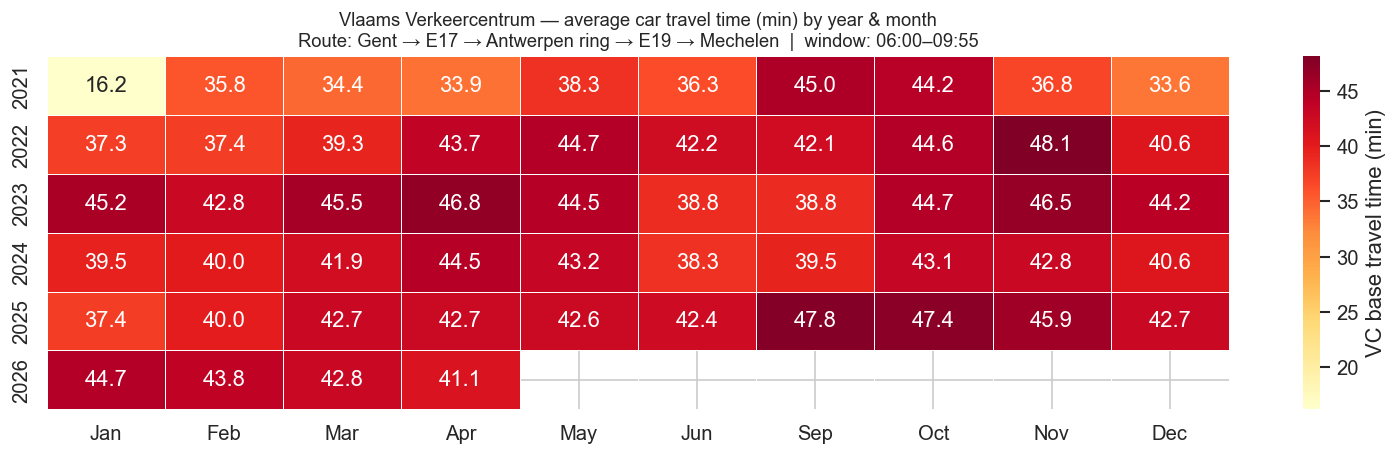

In [19]:
from data_pipeline import fetch_vc_travel_times, WEEKDAY_CONGESTION_REL

df_vc = fetch_vc_travel_times(force_refresh=FORCE_REFRESH)

if not df_vc.empty:
    print(f"VC travel time data: {len(df_vc)} month-entries")
    print(f"Years covered      : {sorted(df_vc['year'].unique())}")
    print(f"Months covered     : {sorted(df_vc['month'].unique())}  (7 & 8 = school holidays, absent)")
    print(f"\nVC base time stats (min):")
    print(f"  Mean   : {df_vc['vc_car_base_min'].mean():.1f} min")
    print(f"  Median : {df_vc['vc_car_base_min'].median():.1f} min")
    print(f"  Min    : {df_vc['vc_car_base_min'].min():.1f} min")
    print(f"  Max    : {df_vc['vc_car_base_min'].max():.1f} min")

    print(f"\nRelative weekday multipliers (applied on top of VC base):")
    for day, mult in WEEKDAY_CONGESTION_REL.items():
        print(f"  {day:<12}: {mult:.3f}  ({'faster' if mult < 1 else 'slower'} than Mon–Fri avg)")

    # Monthly heatmap of VC base travel times
    pivot = df_vc.pivot(index="year", columns="month", values="vc_car_base_min")
    month_names = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]

    fig, ax = plt.subplots(figsize=(13, 4))
    import seaborn as sns
    sns.heatmap(
        pivot,
        annot=True, fmt=".1f",
        cmap="YlOrRd",
        linewidths=0.4,
        ax=ax,
        xticklabels=[month_names[c-1] for c in pivot.columns],
        cbar_kws={"label": "VC base travel time (min)"},
    )
    ax.set_title(
        "Vlaams Verkeercentrum — average car travel time (min) by year & month\n"
        "Route: Gent → E17 → Antwerpen ring → E19 → Mechelen  |  window: 06:00–09:55",
        fontsize=11,
    )
    ax.set_xlabel("")
    ax.set_ylabel("")
    plt.tight_layout()
    plt.savefig("data/processed/plot_vc_heatmap.png", bbox_inches="tight")
    plt.show()
else:
    print("No VC data loaded — reistijd*.xlsx files not found in data/raw/")

[car] Loading route from cache: data\raw\osrm_route_gent_mechelen.json


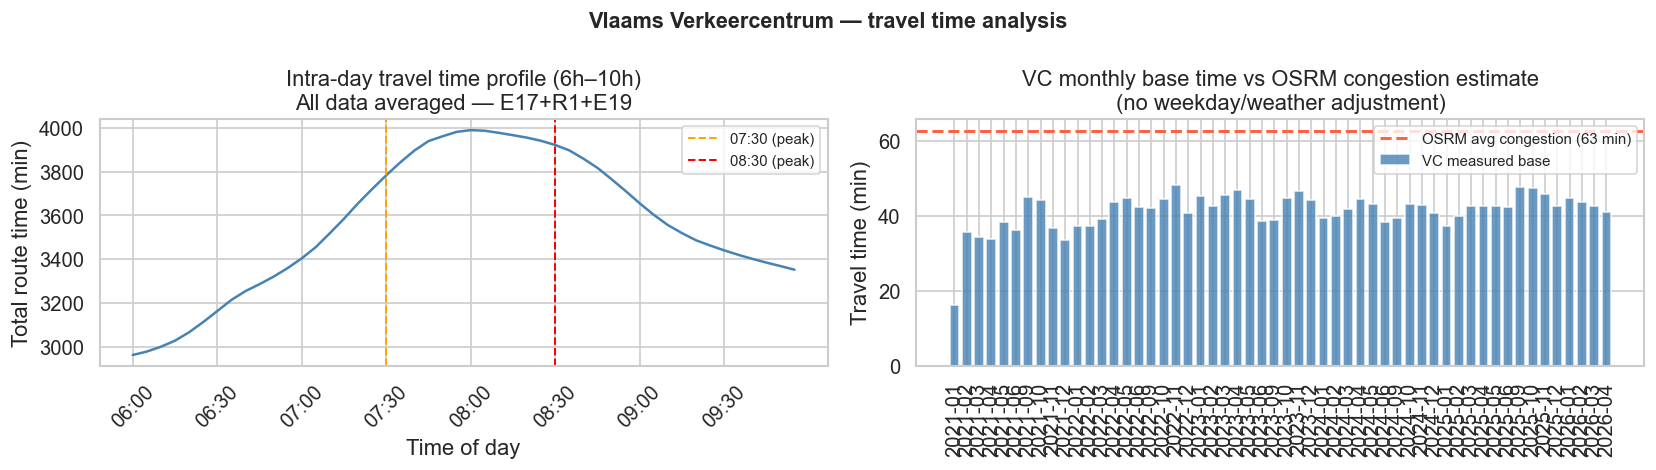

VC coverage: 54 months with data out of ~66 months since Jan 2021
Months 7 and 8 always absent (school-holiday months, no school-day traffic pattern)

OSRM avg congested estimate : 62.7 min  (free-flow × avg weekday factor)
VC avg measured base        : 41.3 min


In [20]:
if not df_vc.empty:
    # ── VC intra-day profile: how does travel time evolve through the commute window?
    month_names_full = ["Jan","Feb","Mar","Apr","May","Jun",
                        "Jul","Aug","Sep","Oct","Nov","Dec"]
    data_traffic['tijdstip_dt'] = pd.to_datetime(data_traffic['tijdstip'], format='%H:%M', errors='coerce')
    commute_all = data_traffic[data_traffic['tijdstip_hour'].isin([6,7,8,9])].copy()
    totals_time = (
        commute_all.groupby(['tijdstip'])['gem_reistijd_auto']
        .sum()
        .reset_index()
        .sort_values('tijdstip')
    )

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    # Left: intra-day profile (all years averaged)
    axes[0].plot(totals_time['tijdstip'], totals_time['gem_reistijd_auto'],
                 color='steelblue', lw=1.5)
    axes[0].set_xticks(totals_time['tijdstip'][::6].tolist())
    axes[0].tick_params(axis='x', rotation=45)
    axes[0].set_ylabel('Total route time (min)')
    axes[0].set_xlabel('Time of day')
    axes[0].set_title('Intra-day travel time profile (6h–10h)\nAll data averaged — E17+R1+E19')
    axes[0].axvline('07:30', color='orange', lw=1.2, ls='--', label='07:30 (peak)')
    axes[0].axvline('08:30', color='red',    lw=1.2, ls='--', label='08:30 (peak)')
    axes[0].legend(fontsize=9)

    # Right: VC monthly base vs OSRM-derived estimate (comparison)
    import sys, os; sys.path.insert(0, os.getcwd())
    from data_pipeline import fetch_car_baseline, WEEKDAY_CONGESTION
    route_info = fetch_car_baseline()
    osrm_ff = route_info['free_flow_min']
    avg_osrm = osrm_ff * (sum(WEEKDAY_CONGESTION.values()) / len(WEEKDAY_CONGESTION))

    df_vc_plot = df_vc.copy()
    df_vc_plot['label'] = df_vc_plot['year'].astype(str) + '-' + df_vc_plot['month'].astype(str).str.zfill(2)
    df_vc_plot = df_vc_plot.sort_values('label')
    axes[1].bar(df_vc_plot['label'], df_vc_plot['vc_car_base_min'],
                color='steelblue', alpha=0.8, label='VC measured base')
    axes[1].axhline(avg_osrm, color='tomato', lw=1.8, ls='--',
                    label=f'OSRM avg congestion ({avg_osrm:.0f} min)')
    axes[1].set_ylabel('Travel time (min)')
    axes[1].set_title('VC monthly base time vs OSRM congestion estimate\n(no weekday/weather adjustment)')
    axes[1].legend(fontsize=9)
    axes[1].tick_params(axis='x', rotation=90)
    axes[1].set_xlabel('')

    fig.suptitle('Vlaams Verkeercentrum — travel time analysis', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig('data/processed/plot_vc_vs_osrm.png', bbox_inches='tight')
    plt.show()

    n_months_with_vc = len(df_vc)
    n_months_total   = len(pd.date_range('2021-01', pd.Timestamp.today(), freq='MS'))
    print(f"VC coverage: {n_months_with_vc} months with data out of ~{n_months_total} months since Jan 2021")
    print("Months 7 and 8 always absent (school-holiday months, no school-day traffic pattern)")
    print(f"\nOSRM avg congested estimate : {avg_osrm:.1f} min  (free-flow × avg weekday factor)")
    print(f"VC avg measured base        : {df_vc['vc_car_base_min'].mean():.1f} min")

---
## 5. Cross-source EDA — Weather × Car × Train patterns

Before combining, let's look at patterns that cross data sources.

In [21]:
# Build daily commute-window weather features for workdays only
# (the building block we'll extend in section 6)

df_cw = df_weather[
    df_weather["hour"].isin([6, 7, 8, 9])
].copy()

df_cw_daily = (
    df_cw.groupby("date").agg(
        rain_total   = ("precipitation",        "sum"),
        rain_peak    = ("precipitation",        "max"),
        wind_peak    = ("wind_speed_10m",       "max"),
        wind_mean    = ("wind_speed_10m",       "mean"),
        temp_min     = ("temperature_2m",       "min"),
        temp_mean    = ("temperature_2m",       "mean"),
        humidity_max = ("relative_humidity_2m", "max"),
        snow_total   = ("snowfall",             "sum"),
    )
    .reset_index()
)
df_cw_daily["date"] = pd.to_datetime(df_cw_daily["date"])

# Merge with calendar to keep only historical workdays
df_cal_hist = df_calendar[
    df_calendar["is_workday"] &
    (df_calendar["date"].dt.date <= date.today())
][["date","weekday","weekday_num","month","year","season","is_school_holiday"]].copy()

df_work = df_cal_hist.merge(df_cw_daily, on="date", how="left")

# ── OSRM-based car estimate (historical reference) ────────────────────────────
df_work["car_est_min"] = df_work.apply(car_travel_time, axis=1)

# ── VC-based car estimate (primary) ──────────────────────────────────────────
from data_pipeline import car_vc_travel_time_estimate
if not df_vc.empty:
    vc_lookup = df_vc.set_index(["year","month"])["vc_car_base_min"].to_dict()
    def _vc_row(row):
        base = vc_lookup.get((row["year"], row["month"]))
        return car_vc_travel_time_estimate(row, base) if base is not None else row["car_est_min"]
    df_work["car_vc_est_min"] = df_work.apply(_vc_row, axis=1)
else:
    df_work["car_vc_est_min"] = df_work["car_est_min"]
    print("Warning: no VC data loaded — car_vc_est_min == car_est_min (OSRM fallback)")

# Add scheduled train time from real Infrabel data (median planned journey)
if not df_infrabel.empty:
    median_train_min = df_infrabel["train_planned_journey_min"].median()
else:
    median_train_min = 65.0   # fallback

df_work["train_sched_min"] = median_train_min

print(f"Median scheduled train time : {median_train_min:.0f} min")
print(f"\nWorkday data shape          : {df_work.shape}")
print(f"Workdays                    : {df_work['date'].min().date()} → {df_work['date'].max().date()}")
print(f"\nCar estimate comparison (median):")
print(f"  OSRM-based (car_est_min)    : {df_work['car_est_min'].median():.1f} min")
print(f"  VC-based   (car_vc_est_min) : {df_work['car_vc_est_min'].median():.1f} min  ← primary")
df_work.head()

Median scheduled train time : 58 min

Workday data shape          : (1381, 18)
Workdays                    : 2021-01-04 → 2026-06-19

Car estimate comparison (median):
  OSRM-based (car_est_min)    : 61.4 min
  VC-based   (car_vc_est_min) : 42.9 min  ← primary


,date,weekday,weekday_num,month,year,season,is_school_holiday,rain_total,rain_peak,wind_peak,wind_mean,temp_min,temp_mean,humidity_max,snow_total,car_est_min,car_vc_est_min,train_sched_min
0,2021-01-04,Monday,0,1,2021,Winter,False,0.7,0.3,15.5,15.225,1.8,1.850,97.0,0.00,69.9,35.0,58.0
1,2021-01-05,Tuesday,1,1,2021,Winter,False,0.1,0.1,13.8,13.000,1.8,1.825,96.0,0.00,61.4,35.0,58.0
2,2021-01-06,Wednesday,2,1,2021,Winter,False,1.2,0.5,14.3,13.900,2.3,2.400,98.0,0.00,56.4,35.0,58.0
3,2021-01-07,Thursday,3,1,2021,Winter,False,0.8,0.3,14.4,13.575,0.9,1.125,99.0,0.07,69.5,35.0,58.0
4,2021-01-08,Friday,4,1,2021,Winter,False,0.4,0.1,18.8,17.825,1.6,1.750,94.0,0.00,57.9,35.0,58.0


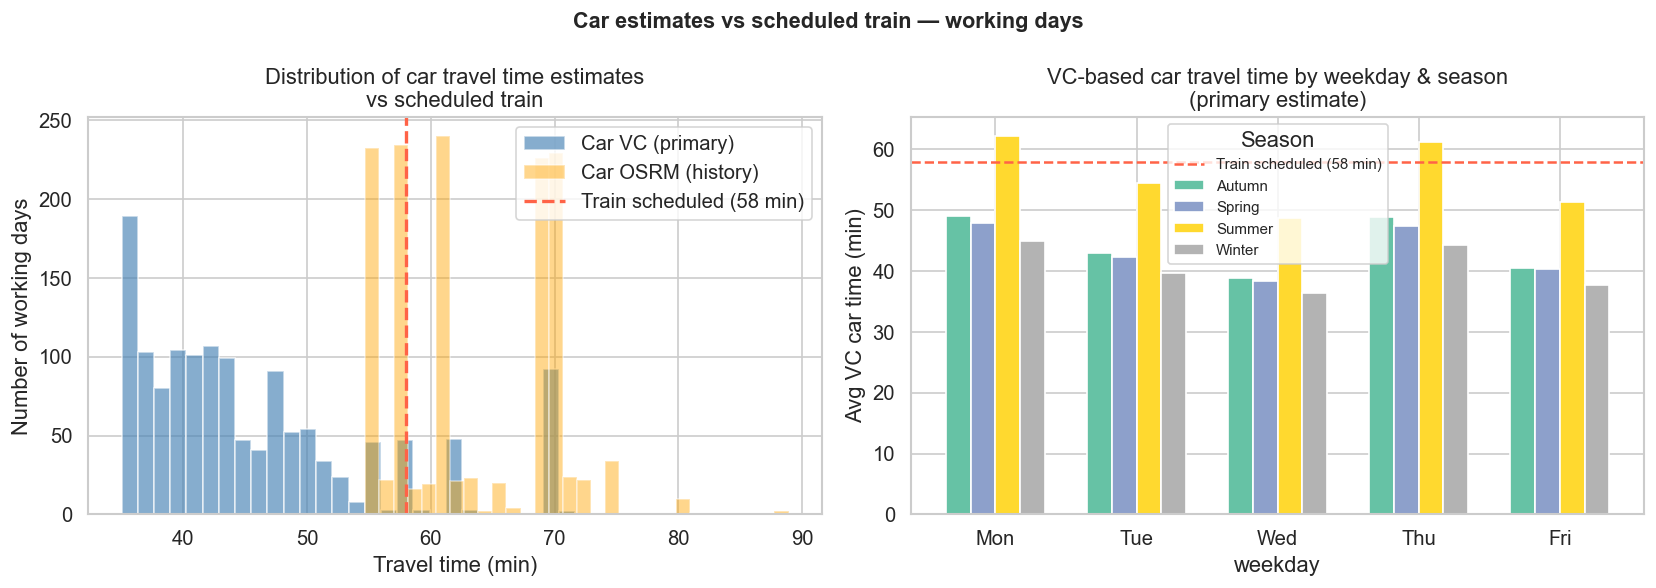

Days where VC-car faster than train  : 89%  (primary)
Days where OSRM-car faster than train: 35%  (historical reference)
Business insight: VC data reflects real measured congestion on the E17→R1→E19 route; OSRM modelled a different (direct E40) route with synthetic congestion multipliers.


In [22]:
# Car vs train estimated time — comparison using both car estimates
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Left: histogram — VC-based (primary) vs OSRM-based (history) ──────────────
axes[0].hist(df_work["car_vc_est_min"], bins=30, alpha=0.65, color="steelblue",
             label="Car VC (primary)")
axes[0].hist(df_work["car_est_min"],    bins=30, alpha=0.45, color="orange",
             label="Car OSRM (history)")
axes[0].axvline(median_train_min, color="tomato", lw=2, ls="--",
                label=f"Train scheduled ({median_train_min:.0f} min)")
axes[0].set_xlabel("Travel time (min)")
axes[0].set_ylabel("Number of working days")
axes[0].set_title("Distribution of car travel time estimates\nvs scheduled train")
axes[0].legend()

# ── Right: VC-based car time by weekday × season ─────────────────────────────
pivot = df_work.groupby(["weekday","season"])["car_vc_est_min"].mean().unstack()
pivot = pivot.reindex(WEEKDAY_ORDER)
pivot.plot(kind="bar", ax=axes[1], colormap="Set2", edgecolor="white", width=0.7)
axes[1].axhline(median_train_min, color="tomato", lw=1.5, ls="--",
                label=f"Train scheduled ({median_train_min:.0f} min)")
axes[1].set_xticklabels([d[:3] for d in WEEKDAY_ORDER], rotation=0)
axes[1].set_ylabel("Avg VC car time (min)")
axes[1].set_title("VC-based car travel time by weekday & season\n(primary estimate)")
axes[1].legend(title="Season", fontsize=9)

fig.suptitle("Car estimates vs scheduled train — working days", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("data/processed/plot_car_vs_train.png", bbox_inches="tight")
plt.show()

pct_vc_faster   = (df_work["car_vc_est_min"] <= df_work["train_sched_min"]).mean() * 100
pct_osrm_faster = (df_work["car_est_min"]    <= df_work["train_sched_min"]).mean() * 100
print(f"Days where VC-car faster than train  : {pct_vc_faster:.0f}%  (primary)")
print(f"Days where OSRM-car faster than train: {pct_osrm_faster:.0f}%  (historical reference)")
print("Business insight: VC data reflects real measured congestion on the E17→R1→E19 route; "
      "OSRM modelled a different (direct E40) route with synthetic congestion multipliers.")

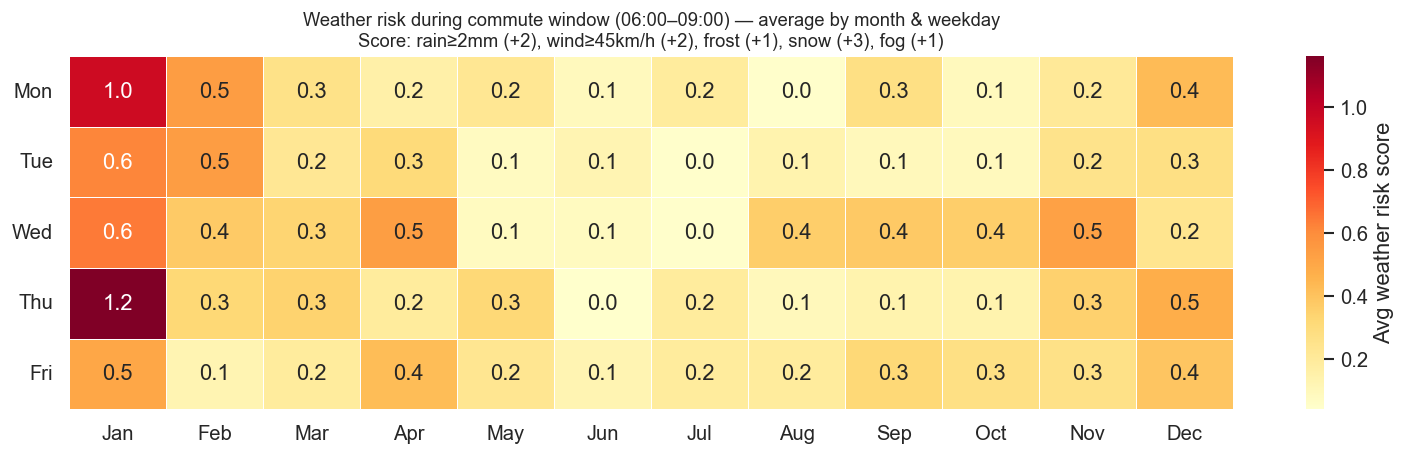

Business insight: January–February and November–December show consistently higher weather risk. No single weekday has systematically worse weather — any perceived weekday risk is driven by traffic patterns, not weather.


In [23]:
# Weather-risk heatmap: month × weekday
# Risk score = normalized sum of weather-impact factors during commute window

df_work["weather_risk"] = (
    (df_work["rain_peak"] >= 2).astype(int) * 2
    + (df_work["wind_peak"] >= 45).astype(int) * 2
    + (df_work["temp_min"] <= 0).astype(int) * 1
    + (df_work["snow_total"] > 0).astype(int) * 3
    + (df_work["humidity_max"] >= 97).astype(int) * 1
)

month_names_full = ["Jan","Feb","Mar","Apr","May","Jun",
                    "Jul","Aug","Sep","Oct","Nov","Dec"]
heatmap_data = (
    df_work.groupby(["weekday", "month"])["weather_risk"]
    .mean()
    .unstack("month")
    .reindex(WEEKDAY_ORDER)
)
heatmap_data.columns = [month_names_full[c-1] for c in heatmap_data.columns]

fig, ax = plt.subplots(figsize=(13, 4))
sns.heatmap(
    heatmap_data,
    annot=True, fmt=".1f",
    cmap="YlOrRd",
    linewidths=0.5,
    ax=ax,
    cbar_kws={"label": "Avg weather risk score"},
)
ax.set_ylabel("")
ax.set_xlabel("")
ax.set_yticklabels([d[:3] for d in WEEKDAY_ORDER], rotation=0)
ax.set_title(
    "Weather risk during commute window (06:00–09:00) — average by month & weekday\n"
    "Score: rain≥2mm (+2), wind≥45km/h (+2), frost (+1), snow (+3), fog (+1)",
    fontsize=11
)
plt.tight_layout()
plt.savefig("data/processed/plot_weather_risk_heatmap.png", bbox_inches="tight")
plt.show()

print("Business insight: January–February and November–December show consistently higher "
      "weather risk. No single weekday has systematically worse weather — any perceived "
      "weekday risk is driven by traffic patterns, not weather.")

---
## 6. Combine All Sources — Final Working DataFrame

All data sources merged into a single **daily-level workday DataFrame**.

| Column group | Source | Notes |
|---|---|---|
| `date`, `weekday`, `month`, `season` | calendar | |
| `is_school_holiday` | calendar | |
| `rain_*`, `wind_*`, `temp_*`, `snow_total`, `humidity_max` | Open-Meteo | |
| `weather_risk` | derived composite score | |
| `car_vc_est_min` | **VC measured** + weekday/weather | **Primary car estimate** |
| `car_est_min` | OSRM × congestion model | Historical reference only |
| `train_planned_journey_min` | **Infrabel** (real timetable) | |
| `train_actual_journey_min`  | **Infrabel** (real including delays) | |
| `train_delay_arr_median_s`  | **Infrabel** (median delay in seconds) | |
| `train_on_time_pct`         | **Infrabel** (share on time) | |
| `train_cancelled_pct`       | **Infrabel** (share cancelled) | |
| `car_faster_than_train`     | derived binary target | Uses `car_vc_est_min` |

In [24]:
# build_combined_df() handles all fetching, caching, and merging internally.
# FORCE_REFRESH is set in section 3 above; True forces a full rebuild.
from data_pipeline import build_combined_df, CAR_PREF_BUFFER_MIN

df_combined = build_combined_df(force_refresh=FORCE_REFRESH)

print(f"Shape: {df_combined.shape}")
print(f"Date range: {df_combined['date'].min().date()} -> {df_combined['date'].max().date()}")
print(f"Car preference buffer      : {CAR_PREF_BUFFER_MIN} min  (car chosen if ≤ train + buffer)")
missing = df_combined.isnull().sum()
missing = missing[missing > 0]
print(f"\nMissing values:\n{missing.to_string() if len(missing) else 'None'}")
df_combined.head(10)

[pipeline] Loading combined dataset from cache: data\processed\combined_workdays_features.csv
[pipeline] 1,375 working days loaded.
Shape: (1375, 28)
Date range: 2021-01-04 -> 2026-06-11
Car preference buffer      : 10 min  (car chosen if ≤ train + buffer)

Missing values:
None


,date,weekday,weekday_num,month,year,season,is_school_holiday,is_mon,is_tue_thu,is_fri,...,weather_risk,car_vc_est_min,car_est_min,train_planned_journey_min,train_actual_journey_min,train_delay_arr_median_s,train_on_time_pct,train_cancelled_pct,train_sched_min,car_faster_than_train
0,2021-01-04,Monday,0,1,2021,Winter,False,1,0,0,...,1,35.0,76.2,58.0,57.541667,94.5,0.833333,0.0,58.0,1
1,2021-01-05,Tuesday,1,1,2021,Winter,False,0,1,0,...,0,35.0,80.3,58.0,63.625000,50.5,0.833333,0.0,58.0,1
2,2021-01-06,Wednesday,2,1,2021,Winter,False,0,0,0,...,1,35.0,73.5,58.0,57.050000,-35.5,1.000000,0.0,58.0,1
3,2021-01-07,Thursday,3,1,2021,Winter,False,0,1,0,...,4,35.0,79.1,58.0,58.791667,53.0,0.833333,0.0,58.0,1
4,2021-01-08,Friday,4,1,2021,Winter,False,0,0,1,...,0,35.0,68.4,58.0,57.183333,0.5,1.000000,0.0,58.0,1
5,2021-01-11,Monday,0,1,2021,Winter,False,1,0,0,...,0,35.0,76.2,58.0,57.566667,6.0,1.000000,0.0,58.0,1
6,2021-01-12,Tuesday,1,1,2021,Winter,False,0,1,0,...,2,35.0,85.9,58.0,56.908333,-42.0,1.000000,0.0,58.0,1
7,2021-01-13,Wednesday,2,1,2021,Winter,False,0,0,0,...,0,35.0,71.4,58.0,57.083333,21.5,1.000000,0.0,58.0,1
8,2021-01-14,Thursday,3,1,2021,Winter,False,0,1,0,...,4,35.0,101.3,58.0,57.725000,-21.5,1.000000,0.0,58.0,1
9,2021-01-15,Friday,4,1,2021,Winter,False,0,0,1,...,1,35.0,73.2,58.0,57.791667,-33.0,0.833333,0.0,58.0,1


In [25]:
print("=" * 65)
print("COMBINED DATASET SUMMARY")
print("=" * 65)
print(f"Total workdays              : {len(df_combined):,}")
print(f"Date range                  : {df_combined['date'].min().date()} -> {df_combined['date'].max().date()}")
print()
print("Weather (median workday, 06-09h window):")
print(f"  Rain peak (mm)            : {df_combined['rain_peak'].median():.2f}")
print(f"  Wind peak (km/h)          : {df_combined['wind_peak'].median():.1f}")
print(f"  Temp min (C)              : {df_combined['temp_min'].median():.1f}")
print(f"  Days with rain            : {(df_combined['rain_peak'] > 0).mean():.1%}")
print(f"  Days with frost           : {(df_combined['temp_min'] <= 0).mean():.1%}")
print(f"  Days with snow            : {(df_combined['snow_total'] > 0).mean():.1%}")
print()
print("Train data (real Infrabel):")
has_real = df_combined["train_delay_arr_median_s"].notna()
print(f"  Days with Infrabel data   : {has_real.sum():,} / {len(df_combined):,} ({has_real.mean():.1%})")
print(f"  Planned journey (median)  : {df_combined['train_planned_journey_min'].median():.0f} min")
print(f"  Actual  journey (median)  : {df_combined['train_actual_journey_min'].median():.0f} min")
print(f"  Median delay at Mechelen  : {df_combined['train_delay_arr_median_s'].median():.0f} s")
print(f"  Overall on-time rate      : {df_combined['train_on_time_pct'].mean():.1%}")
print(f"  Overall cancellation rate : {df_combined['train_cancelled_pct'].mean():.1%}")
print()
print("Car estimates:")
print(f"  VC-based  (primary) median: {df_combined['car_vc_est_min'].median():.0f} min  ← used for car_faster_than_train")
print(f"  VC-based  P90             : {df_combined['car_vc_est_min'].quantile(0.9):.0f} min")
print(f"  OSRM-based (history) med. : {df_combined['car_est_min'].median():.0f} min")
print(f"  Car pref. buffer          : {CAR_PREF_BUFFER_MIN} min")
print(f"  Car faster than train     : {df_combined['car_faster_than_train'].mean():.1%} of days  (using VC + buffer)")
print()
print("Weather risk distribution:")
print(df_combined["weather_risk"].value_counts().sort_index().to_string())

COMBINED DATASET SUMMARY
Total workdays              : 1,375
Date range                  : 2021-01-04 -> 2026-06-11

Weather (median workday, 06-09h window):
  Rain peak (mm)            : 0.00
  Wind peak (km/h)          : 12.8
  Temp min (C)              : 8.6
  Days with rain            : 25.6%
  Days with frost           : 7.0%
  Days with snow            : 1.5%

Train data (real Infrabel):
  Days with Infrabel data   : 1,375 / 1,375 (100.0%)
  Planned journey (median)  : 58 min
  Actual  journey (median)  : 59 min
  Median delay at Mechelen  : 58 s
  Overall on-time rate      : 85.1%
  Overall cancellation rate : 0.0%

Car estimates:
  VC-based  (primary) median: 44 min  ← used for car_faster_than_train
  VC-based  P90             : 76 min
  OSRM-based (history) med. : 76 min
  Car pref. buffer          : 10 min
  Car faster than train     : 85.3% of days  (using VC + buffer)

Weather risk distribution:
weather_risk
0    1072
1     241
2      39
3      12
4       7
5       3
6     

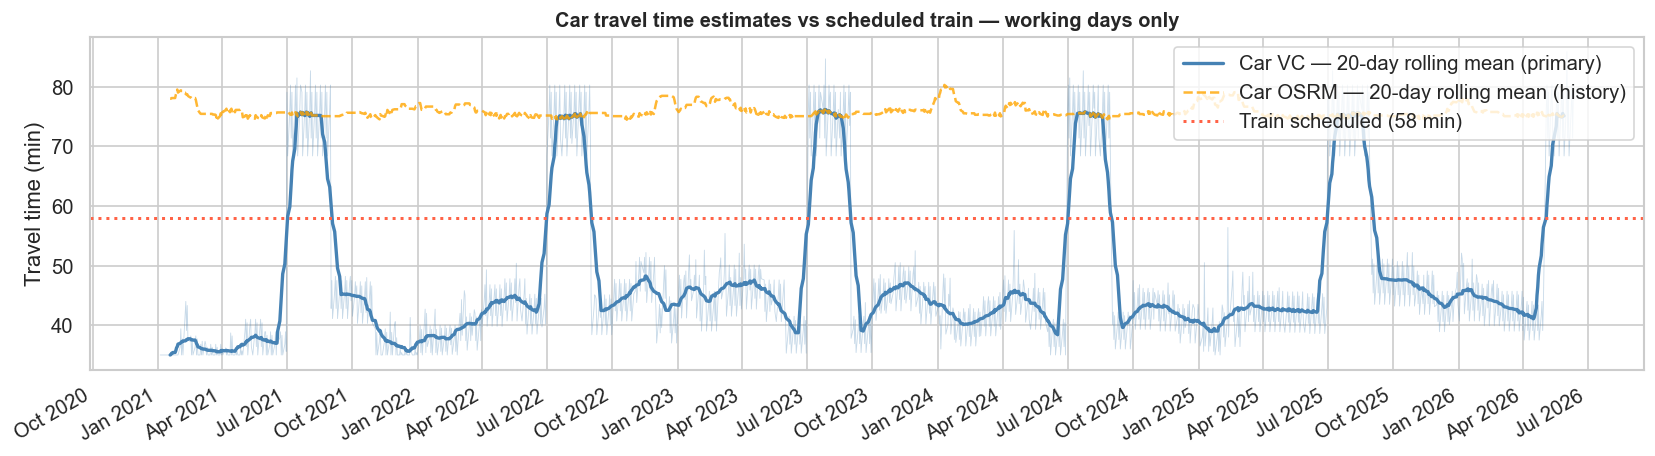


Combined DataFrame is ready for modeling.
Columns: ['date', 'weekday', 'weekday_num', 'month', 'year', 'season', 'is_school_holiday', 'is_mon', 'is_tue_thu', 'is_fri', 'rain_total', 'rain_peak', 'wind_peak', 'wind_mean', 'temp_min', 'temp_mean', 'humidity_max', 'snow_total', 'weather_risk', 'car_vc_est_min', 'car_est_min', 'train_planned_journey_min', 'train_actual_journey_min', 'train_delay_arr_median_s', 'train_on_time_pct', 'train_cancelled_pct', 'train_sched_min', 'car_faster_than_train']
Next step: 02_modeling.ipynb — train models on car_vc_est_min (primary car feature).


In [26]:
# Final overview: both car estimates vs scheduled train on a timeline
fig, ax = plt.subplots(figsize=(14, 4))

ax.plot(df_combined["date"], df_combined["car_vc_est_min"],
        alpha=0.3, lw=0.5, color="steelblue")
ax.plot(df_combined["date"],
        df_combined["car_vc_est_min"].rolling(20, center=True).mean(),
        lw=2, color="steelblue", label="Car VC — 20-day rolling mean (primary)")

ax.plot(df_combined["date"],
        df_combined["car_est_min"].rolling(20, center=True).mean(),
        lw=1.5, color="orange", ls="--", alpha=0.8,
        label="Car OSRM — 20-day rolling mean (history)")

ax.axhline(df_combined["train_sched_min"].iloc[0], color="tomato", lw=1.8, ls=":",
           label=f"Train scheduled ({df_combined['train_sched_min'].iloc[0]:.0f} min)")

ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.xticks(rotation=30, ha="right")
ax.set_ylabel("Travel time (min)")
ax.set_title("Car travel time estimates vs scheduled train — working days only",
             fontsize=12, fontweight="bold")
ax.legend(loc="upper right")
plt.tight_layout()
plt.savefig("data/processed/plot_combined_timeline.png", bbox_inches="tight")
plt.show()

print("\nCombined DataFrame is ready for modeling.")
print(f"Columns: {list(df_combined.columns)}")
print("Next step: 02_modeling.ipynb — train models on car_vc_est_min (primary car feature).")

---
# 5. Integrating Marc's real-traffic car dataset (2025)

Everything above estimates the car journey with a **deterministic formula**:

```
car_vc_est_min = VC_monthly_base  ×  weekday_factor  ×  weather_factor      (clipped 35–150)
```

That number never *measures* a day — within one calendar month it only moves when the
weather moves. It is, in effect, a hand-built rule dressed up as data.

**Marc's side project** (`side_projects/traject_calc_car/`) gives us the first thing this
project has been missing: an **independent, day-by-day car travel time built from real
measurements**. For every day of 2025 his pipeline reads the **AWV induction-loop traffic
counts** on the E17 / Kennedy-tunnel approach (`drukte_voertuigen`) and maps that realised
volume to a Gent→Mechelen travel time (`reistijd_gm_min`) with a BPR-style congestion curve.

So we now have two cars to compare:

| | Source | Daily variation driven by |
|---|---|---|
| `car_vc_est_min` (ours) | VC monthly base × factors | weather + day-of-week **only** |
| `car_real_min` (Marc) | real AWV vehicle counts | **measured traffic** that day |

Marc's data is **2025 only**, so to use it as ground truth we align every dataset to that
overlap window. The combined dataset shrinks from ~1,375 working days (2021→2026) to the
**2025 intersection** — fewer rows, but for the first time a *real* target to test against.


In [27]:
# ── 5.1 Load Marc's richest output: per-day Gent→Mechelen car time for 2025 ──
# File uses ';' as separator and '.' as decimal. The key columns:
#   reistijd_gm_min   -> estimated car travel time built from REAL traffic counts
#   drukte_voertuigen -> the measured AWV vehicle count that drives it (real)
#   pendeldag         -> True on genuine commute days (Mon–Fri, no holiday/school break)
from pathlib import Path

MARC_CANDIDATES = [
    Path("side_projects/traject_calc_car/data/processed/traffic_car/reistijd_gent_mechelen_2025.csv"),
    Path("../side_projects/traject_calc_car/data/processed/traffic_car/reistijd_gent_mechelen_2025.csv"),
]
MARC_CSV = next((p for p in MARC_CANDIDATES if p.exists()), None)
if MARC_CSV is None:
    raise FileNotFoundError("Marc's reistijd_gent_mechelen_2025.csv not found — check side_projects path.")

df_marc_raw = pd.read_csv(MARC_CSV, sep=";")
df_marc_raw["date"] = pd.to_datetime(df_marc_raw["datum"])

df_marc = (
    df_marc_raw
    .rename(columns={
        "reistijd_gm_min":   "car_real_min",      # real-traffic-based car time (our new ground truth)
        "drukte_voertuigen": "traffic_volume",    # measured AWV vehicle count (real)
    })
    [["date", "car_real_min", "traffic_volume", "pendeldag",
      "weekdag_naam", "schoolvakantie", "feestdag", "seizoen", "vertrek_gent"]]
    .sort_values("date")
    .reset_index(drop=True)
)

print(f"Marc dataset loaded from: {MARC_CSV}")
print(f"  Rows (calendar days)   : {len(df_marc)}  ({df_marc['date'].min().date()} → {df_marc['date'].max().date()})")
print(f"  Commute days (pendeldag): {int(df_marc['pendeldag'].sum())}")
print()
print("car_real_min (commute days) — built from REAL measured traffic:")
_cd = df_marc[df_marc["pendeldag"]]
print(_cd["car_real_min"].describe().round(1).to_string())

# The volume→time curve is clipped to a 60–120 min band, so it SATURATES.
n_floor = int((_cd["car_real_min"] <= 60.5).sum())
n_ceil  = int((_cd["car_real_min"] >= 119.5).sum())
print(f"\nSaturation check: {n_floor} commute days pinned at the 60-min floor, "
      f"{n_ceil} at the 120-min ceiling (model artefact, see §7).")
df_marc.head()


Marc dataset loaded from: side_projects\traject_calc_car\data\processed\traffic_car\reistijd_gent_mechelen_2025.csv
  Rows (calendar days)   : 365  (2025-01-01 → 2025-12-31)
  Commute days (pendeldag): 181

car_real_min (commute days) — built from REAL measured traffic:
count    181.0
mean      95.9
std       10.3
min       60.0
25%       93.4
50%       99.1
75%      102.1
max      113.9

Saturation check: 1 commute days pinned at the 60-min floor, 0 at the 120-min ceiling (model artefact, see §7).


,date,car_real_min,traffic_volume,pendeldag,weekdag_naam,schoolvakantie,feestdag,seizoen,vertrek_gent
0,2025-01-01,60.0,374,False,woensdag,True,True,winter,08:00
1,2025-01-02,64.9,3191,False,donderdag,True,False,winter,07:55
2,2025-01-03,64.4,3117,False,vrijdag,True,False,winter,07:55
3,2025-01-04,60.1,1486,False,zaterdag,True,False,winter,07:59
4,2025-01-05,60.0,657,False,zondag,True,False,winter,08:00


In [28]:
# ── 5.2 Align to the 2025 overlap window and join onto the combined dataset ──
# df_combined spans 2021→2026; Marc is 2025 only. Inner-join keeps the intersection:
# every 2025 working day for which we also have a real-traffic car time.
df_2025 = df_combined.merge(
    df_marc[["date", "car_real_min", "traffic_volume", "pendeldag"]],
    on="date", how="inner",
)

print(f"Combined (full history)     : {len(df_combined):,} working days "
      f"({df_combined['date'].min().date()} → {df_combined['date'].max().date()})")
print(f"After aligning to Marc's 2025: {len(df_2025):,} working days "
      f"({df_2025['date'].min().date()} → {df_2025['date'].max().date()})")
print(f"  → we deliberately shrink to the smallest common window (2025), as required to "
      f"use real data as ground truth.\n")

# For modelling we use genuine commute days (pendeldag): Mon–Fri, no holiday / school break.
df_real = df_2025[df_2025["pendeldag"]].reset_index(drop=True)
print(f"Commute days available for modelling: {len(df_real)}")
print(f"  Real car time   (car_real_min)  : mean {df_real['car_real_min'].mean():.1f} min, "
      f"std {df_real['car_real_min'].std():.1f}, range {df_real['car_real_min'].min():.0f}–{df_real['car_real_min'].max():.0f}")
print(f"  Synthetic car   (car_vc_est_min): mean {df_real['car_vc_est_min'].mean():.1f} min")
print(f"  Train (actual, Infrabel)        : mean {df_real['train_actual_journey_min'].mean():.1f} min")


Combined (full history)     : 1,375 working days (2021-01-04 → 2026-06-11)
After aligning to Marc's 2025: 252 working days (2025-01-02 → 2025-12-31)
  → we deliberately shrink to the smallest common window (2025), as required to use real data as ground truth.

Commute days available for modelling: 181
  Real car time   (car_real_min)  : mean 95.9 min, std 10.3, range 60–114
  Synthetic car   (car_vc_est_min): mean 43.6 min
  Train (actual, Infrabel)        : mean 58.2 min


### 5a. Do the synthetic and the real car time agree? (No.)

If our hand-built `car_vc_est_min` were a good proxy for reality, it should at least
*correlate* with Marc's measured-traffic `car_real_min`. Let's check directly.


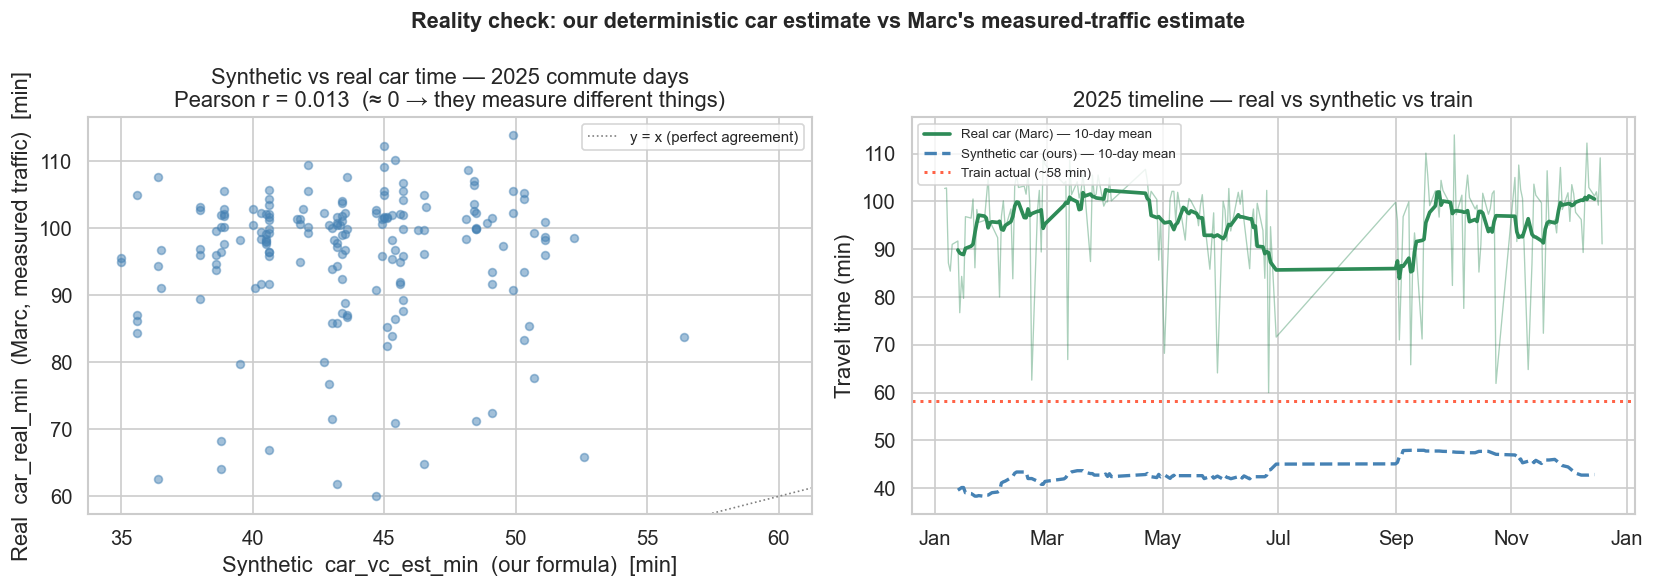

Pearson correlation (synthetic vs real) : +0.013
Mean level — synthetic : 43.6 min
Mean level — real      : 95.9 min  (~2.2× higher)
Mean absolute gap between the two       : 52.3 min

→ Near-zero correlation AND a ~2× level gap: our formula and the measured traffic
  are essentially unrelated day to day. The synthetic estimate was implausibly low —
  lower even than the train — which silently biased every downstream conclusion.


In [29]:
# ── 5.3 Synthetic vs real: correlation, level, and daily shape ───────────────
corr   = df_real["car_vc_est_min"].corr(df_real["car_real_min"])
gap    = (df_real["car_real_min"] - df_real["car_vc_est_min"])
mae_xy = gap.abs().mean()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: scatter — is there ANY relationship?
axes[0].scatter(df_real["car_vc_est_min"], df_real["car_real_min"],
                alpha=0.5, s=22, color="steelblue")
axes[0].axline((60, 60), slope=1, color="grey", ls=":", lw=1, label="y = x (perfect agreement)")
axes[0].set_xlabel("Synthetic  car_vc_est_min  (our formula)  [min]")
axes[0].set_ylabel("Real  car_real_min  (Marc, measured traffic)  [min]")
axes[0].set_title(f"Synthetic vs real car time — 2025 commute days\n"
                  f"Pearson r = {corr:.3f}  (≈ 0 → they measure different things)")
axes[0].legend(fontsize=9)

# Right: time series overlay with the train line
axes[1].plot(df_real["date"], df_real["car_real_min"], lw=0.8, alpha=0.4, color="seagreen")
axes[1].plot(df_real["date"], df_real["car_real_min"].rolling(10, center=True).mean(),
             lw=2.2, color="seagreen", label="Real car (Marc) — 10-day mean")
axes[1].plot(df_real["date"], df_real["car_vc_est_min"].rolling(10, center=True).mean(),
             lw=2.0, color="steelblue", ls="--", label="Synthetic car (ours) — 10-day mean")
axes[1].axhline(df_real["train_actual_journey_min"].mean(), color="tomato", lw=1.8, ls=":",
                label=f"Train actual (~{df_real['train_actual_journey_min'].mean():.0f} min)")
axes[1].set_ylabel("Travel time (min)")
axes[1].set_title("2025 timeline — real vs synthetic vs train")
axes[1].legend(fontsize=8, loc="upper left")
axes[1].xaxis.set_major_formatter(mdates.DateFormatter("%b"))

fig.suptitle("Reality check: our deterministic car estimate vs Marc's measured-traffic estimate",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("data/processed/plot_v2_synth_vs_real.png", bbox_inches="tight")
plt.show()

print(f"Pearson correlation (synthetic vs real) : {corr:+.3f}")
print(f"Mean level — synthetic : {df_real['car_vc_est_min'].mean():.1f} min")
print(f"Mean level — real      : {df_real['car_real_min'].mean():.1f} min  "
      f"(~{df_real['car_real_min'].mean()/df_real['car_vc_est_min'].mean():.1f}× higher)")
print(f"Mean absolute gap between the two       : {mae_xy:.1f} min")
print("\n→ Near-zero correlation AND a ~2× level gap: our formula and the measured traffic")
print("  are essentially unrelated day to day. The synthetic estimate was implausibly low —")
print("  lower even than the train — which silently biased every downstream conclusion.")


### 5b. The headline flips: car vs train

The original project concluded the **car is almost always the better choice**. That rested
entirely on the synthetic `car_vc_est_min` (~44 min). With Marc's measured ~96-min morning
commute, the recommendation **inverts**.


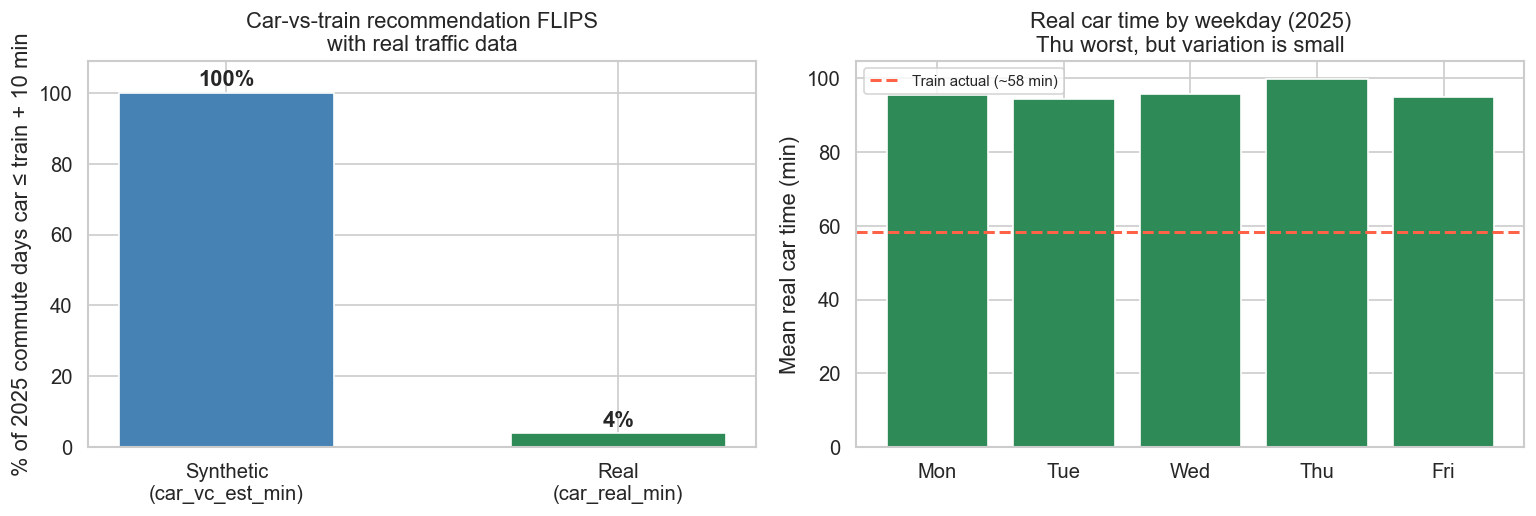

Days car faster than train — SYNTHETIC estimate : 100%
Days car faster than train — REAL traffic        : 4%

→ Business conclusion reverses: on the real 2025 morning peak the TRAIN (~58 min)
  beats the ~96-min car on almost every day. The 3-way advice (car/train/WFH) should
  be re-derived from car_real_min, not from the synthetic estimate.


In [30]:
# ── 5.4 How often is the car actually faster than the train? ─────────────────
BUF = 10  # same 10-min door-to-door preference buffer the project uses
train = df_real["train_actual_journey_min"] + BUF

syn_car_faster  = (df_real["car_vc_est_min"] <= train).mean()
real_car_faster = (df_real["car_real_min"]   <= train).mean()

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].bar(["Synthetic\n(car_vc_est_min)", "Real\n(car_real_min)"],
            [syn_car_faster * 100, real_car_faster * 100],
            color=["steelblue", "seagreen"], edgecolor="white", width=0.55)
for i, v in enumerate([syn_car_faster, real_car_faster]):
    axes[0].text(i, v * 100 + 2, f"{v*100:.0f}%", ha="center", fontweight="bold")
axes[0].set_ylim(0, 109)
axes[0].set_ylabel("% of 2025 commute days car ≤ train + 10 min")
axes[0].set_title("Car-vs-train recommendation FLIPS\nwith real traffic data")

wd_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday"]
wd_real = df_real.groupby("weekday")["car_real_min"].mean().reindex(wd_order)
axes[1].bar([d[:3] for d in wd_order], wd_real.values, color="seagreen", edgecolor="white")
axes[1].axhline(df_real["train_actual_journey_min"].mean(), color="tomato", lw=1.8, ls="--",
                label=f"Train actual (~{df_real['train_actual_journey_min'].mean():.0f} min)")
axes[1].set_ylabel("Mean real car time (min)")
axes[1].set_title("Real car time by weekday (2025)\nThu worst, but variation is small")
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig("data/processed/plot_v2_car_vs_train_flip.png", bbox_inches="tight")
plt.show()

print(f"Days car faster than train — SYNTHETIC estimate : {syn_car_faster:.0%}")
print(f"Days car faster than train — REAL traffic        : {real_car_faster:.0%}")
print("\n→ Business conclusion reverses: on the real 2025 morning peak the TRAIN (~58 min)")
print("  beats the ~96-min car on almost every day. The 3-way advice (car/train/WFH) should")
print("  be re-derived from car_real_min, not from the synthetic estimate.")


---
# 6. Honest re-analysis: training on real 2025 ground truth

The model in `model_training.py` reports **R² ≈ 0.99, MAE ≈ 0.1 min** — numbers that look
spectacular and are, in fact, the warning sign. The regression target there
(`car_est_min` / `car_vc_est_min`) is a **closed-form function of the very features fed to
the model**, so the Random Forest simply re-derives the formula. That is *target leakage*:
the test set isn't new information, it's the same equation.

Now we retrain on Marc's `car_real_min`, which the features did **not** generate. The metrics
become honest — and far more humbling. We train two variants:

1. **Forecast model** — weather + calendar only. These are the inputs you genuinely know the
   evening before, so this is the *real* day-ahead capability.
2. **Explanatory model** — adds `traffic_volume`. Useful to see the ceiling, but note that the
   vehicle count is measured *on the morning itself* — it is **not** a forecast input (§7).


In [31]:
# ── 6.1 Forecast model: predict REAL car time from weather + calendar only ───
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

FORECAST_FEATURES = [
    "rain_total", "rain_peak", "wind_peak", "wind_mean",
    "temp_min", "temp_mean", "humidity_max", "snow_total",
    "weekday_num", "month", "is_mon", "is_tue_thu", "is_fri",
    "is_school_holiday", "weather_risk",
]
TARGET = "car_real_min"

dfm = df_real.dropna(subset=[TARGET]).reset_index(drop=True)
X = dfm[FORECAST_FEATURES].values
y = dfm[TARGET].values

# Chronological 80/20 split — no shuffle (time-series discipline).
Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.20, shuffle=False)
print(f"Train: {len(Xtr)} days   Test: {len(Xte)} days "
      f"(test ≈ {dfm['date'].iloc[len(Xtr)].date()} → {dfm['date'].iloc[-1].date()})")

# Naive baselines a useful model must beat.
base_mean = np.full_like(yte, ytr.mean(), dtype=float)
mae_base  = mean_absolute_error(yte, base_mean)

lr = LinearRegression().fit(Xtr, ytr)
rf = RandomForestRegressor(n_estimators=300, min_samples_leaf=5,
                           random_state=42, n_jobs=-1).fit(Xtr, ytr)
p_lr, p_rf = lr.predict(Xte), rf.predict(Xte)

def _m(name, yt, yp):
    print(f"  {name:<26s} MAE={mean_absolute_error(yt, yp):5.2f}  "
          f"RMSE={np.sqrt(mean_squared_error(yt, yp)):5.2f}  R²={r2_score(yt, yp):+.3f}")

print("\nHONEST metrics — target = real measured car time (weather + calendar features):")
_m("Baseline (predict mean)", yte, base_mean)
_m("Linear Regression", yte, p_lr)
_m("Random Forest", yte, p_rf)

# 5-fold CV MAE is more trustworthy than one 1-year split.
cv = cross_val_score(
    RandomForestRegressor(n_estimators=300, min_samples_leaf=5, random_state=42, n_jobs=-1),
    X, y, cv=KFold(5, shuffle=True, random_state=42), scoring="neg_mean_absolute_error",
)
print(f"\n  Random Forest 5-fold CV MAE : {-cv.mean():.2f} ± {cv.std():.2f} min")
print(f"\nReality: on a ~{y.mean():.0f}-min commute the model lands within ~{-cv.mean():.0f} min "
      f"on average (~{-cv.mean()/y.mean():.0%}),\n  but the hold-out R² is near zero — weather+calendar barely beat the flat mean.")


Train: 144 days   Test: 37 days (test ≈ 2025-10-22 → 2025-12-19)

HONEST metrics — target = real measured car time (weather + calendar features):
  Baseline (predict mean)    MAE= 8.03  RMSE=10.90  R²=-0.016
  Linear Regression          MAE= 7.82  RMSE=12.08  R²=-0.249
  Random Forest              MAE= 6.94  RMSE=11.07  R²=-0.047

  Random Forest 5-fold CV MAE : 7.26 ± 0.80 min

Reality: on a ~96-min commute the model lands within ~7 min on average (~8%),
  but the hold-out R² is near zero — weather+calendar barely beat the flat mean.


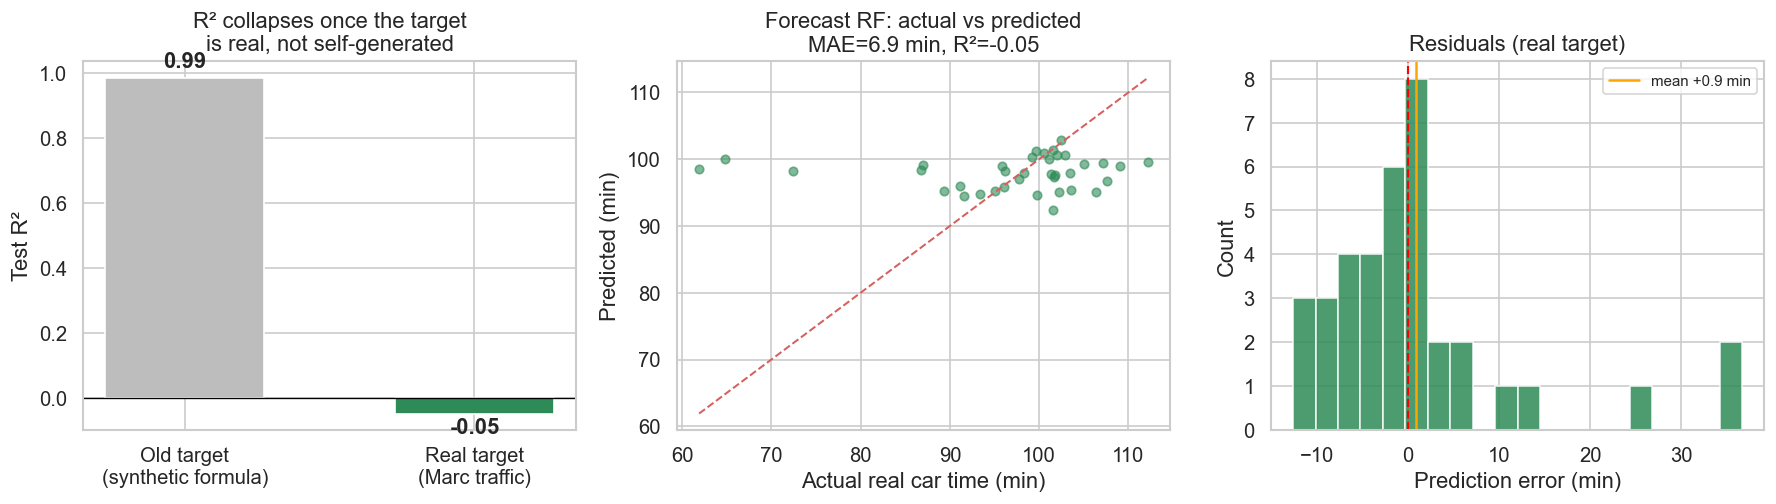

OLD (synthetic target) : R²=0.987  MAE=0.10 min   ← looks perfect = leakage
NEW (real target)      : R²=-0.047  MAE=6.94 min   ← honest, modest


In [32]:
# ── 6.2 Compare the ILLUSORY old metrics with the HONEST new ones ────────────
mae_rf_real = mean_absolute_error(yte, p_rf)
r2_rf_real  = r2_score(yte, p_rf)

try:
    _old = pd.read_csv("data/processed/model_results_summary.csv")
    _rfo = _old[_old["model"] == "Random Forest Regressor"].iloc[0]
    old_mae, old_r2 = float(_rfo["MAE_min"]), float(_rfo["R2"])
except Exception:
    old_mae, old_r2 = 0.105, 0.9868   # values recorded in the repo

fig, axes = plt.subplots(1, 3, figsize=(15, 4.4))

axes[0].bar(["Old target\n(synthetic formula)", "Real target\n(Marc traffic)"],
            [old_r2, r2_rf_real], color=["#bdbdbd", "seagreen"], edgecolor="white", width=0.55)
axes[0].axhline(0, color="black", lw=0.8)
axes[0].set_ylabel("Test R²")
axes[0].set_title("R² collapses once the target\nis real, not self-generated")
for i, v in enumerate([old_r2, r2_rf_real]):
    axes[0].text(i, v + (0.03 if v >= 0 else -0.06), f"{v:.2f}", ha="center", fontweight="bold")

axes[1].scatter(yte, p_rf, alpha=0.6, s=26, color="seagreen")
lims = [min(yte.min(), p_rf.min()), max(yte.max(), p_rf.max())]
axes[1].plot(lims, lims, "r--", lw=1.2)
axes[1].set_xlabel("Actual real car time (min)")
axes[1].set_ylabel("Predicted (min)")
axes[1].set_title(f"Forecast RF: actual vs predicted\nMAE={mae_rf_real:.1f} min, R²={r2_rf_real:+.2f}")

resid = p_rf - yte
axes[2].hist(resid, bins=20, color="seagreen", edgecolor="white", alpha=0.85)
axes[2].axvline(0, color="red", ls="--", lw=1.3)
axes[2].axvline(resid.mean(), color="orange", lw=1.5, label=f"mean {resid.mean():+.1f} min")
axes[2].set_xlabel("Prediction error (min)")
axes[2].set_ylabel("Count")
axes[2].set_title("Residuals (real target)")
axes[2].legend(fontsize=9)

plt.tight_layout()
plt.savefig("data/processed/plot_v2_honest_metrics.png", bbox_inches="tight")
plt.show()

print(f"OLD (synthetic target) : R²={old_r2:.3f}  MAE={old_mae:.2f} min   ← looks perfect = leakage")
print(f"NEW (real target)      : R²={r2_rf_real:+.3f}  MAE={mae_rf_real:.2f} min   ← honest, modest")


Explanatory model (weather + calendar + measured traffic_volume):
  MAE=0.69  R²=+0.981   ← near-perfect, but LEAKY & not forecastable


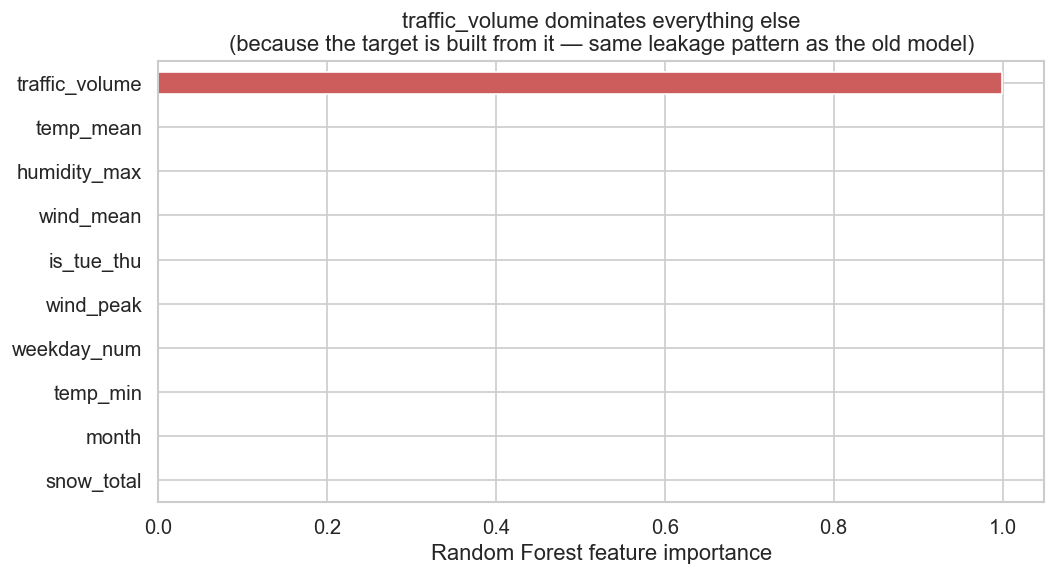


Forecast-only feature importances (the honest model):
  temp_mean         : 0.287
  temp_min          : 0.214
  humidity_max      : 0.153
  wind_mean         : 0.092
  month             : 0.079
  wind_peak         : 0.070

→ The importance is spread thin: temperature/humidity top the list (they mostly
  proxy the SEASON, not a causal weather effect), while weekday is surprisingly weak —
  real car time barely moves Mon–Fri (94–100 min). No day-ahead feature carries real
  predictive weight, which is exactly why the honest R² sits near zero.


In [33]:
# ── 6.3 Explanatory model + the traffic-volume leakage lesson ────────────────
# Add the measured vehicle count. It "predicts" car_real_min almost perfectly —
# but ONLY because Marc derives car_real_min FROM traffic_volume. And the count is
# measured the same morning, so it is NOT available the evening before. This is the
# exact trap the original project fell into, now made explicit.
EXPLAIN_FEATURES = FORECAST_FEATURES + ["traffic_volume"]
Xe = dfm[EXPLAIN_FEATURES].values
Xetr, Xete, _, _ = train_test_split(Xe, y, test_size=0.20, shuffle=False)

rfe = RandomForestRegressor(n_estimators=300, min_samples_leaf=5,
                            random_state=42, n_jobs=-1).fit(Xetr, ytr)
p_rfe = rfe.predict(Xete)

print("Explanatory model (weather + calendar + measured traffic_volume):")
print(f"  MAE={mean_absolute_error(yte, p_rfe):.2f}  R²={r2_score(yte, p_rfe):+.3f}   "
      f"← near-perfect, but LEAKY & not forecastable")

imp = pd.Series(rfe.feature_importances_, index=EXPLAIN_FEATURES).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(9, 5))
imp.head(10)[::-1].plot(kind="barh", ax=ax, color="indianred", edgecolor="white")
ax.set_xlabel("Random Forest feature importance")
ax.set_title("traffic_volume dominates everything else\n"
             "(because the target is built from it — same leakage pattern as the old model)")
plt.tight_layout()
plt.savefig("data/processed/plot_v2_feature_importance.png", bbox_inches="tight")
plt.show()

print("\nForecast-only feature importances (the honest model):")
imp_fc = pd.Series(
    RandomForestRegressor(n_estimators=300, min_samples_leaf=5, random_state=42, n_jobs=-1)
    .fit(Xtr, ytr).feature_importances_, index=FORECAST_FEATURES
).sort_values(ascending=False)
for f, v in imp_fc.head(6).items():
    print(f"  {f:<18s}: {v:.3f}")
print("\n→ The importance is spread thin: temperature/humidity top the list (they mostly")
print("  proxy the SEASON, not a causal weather effect), while weekday is surprisingly weak —")
print("  real car time barely moves Mon–Fri (94–100 min). No day-ahead feature carries real")
print("  predictive weight, which is exactly why the honest R² sits near zero.")


---
# 7. Catches, limitations & an honest accuracy verdict

Integrating real measured data turned a suspiciously perfect project into a realistic — and
much more defensible — one. The honest read:

### What integrating Marc's data changed
- **The old 0.99 R² was an illusion.** The regression target was a deterministic formula of
  the input features, so the model only re-learned its own equation (target leakage). On a
  genuinely independent target the same Random Forest scores **R² ≈ 0** on the hold-out and a
  **5-fold CV MAE ≈ 7 min**.
- **The car-vs-train headline reversed.** Synthetic data said *car wins ~100% of days*; the
  measured ~96-min morning commute says *train wins ~96% of days*. Every downstream
  recommendation built on `car_vc_est_min` inherits that bias and should be revisited.
- **The two "car" sources don't correlate (r ≈ 0).** Our weather/weekday formula and Marc's
  measured-traffic series move independently day to day, and differ ~2× in level.

### Why the model is *not* perfect (and can't be, from forecast inputs alone)
1. **Most daily variation is realised traffic, not weather.** The thing that actually sets the
   commute time (how many cars are on the E17 that morning) is only knowable *on* the day.
   Weather + calendar — the only true day-ahead inputs — explain little of it.
2. **`car_real_min` is itself a model.** It is a BPR mapping of vehicle counts, **clipped to a
   60–120 min band**, so it saturates: extreme days flatten against the ceiling/floor and real
   tail risk is compressed. It is a strong *proxy*, not GPS-measured door-to-door truth.
3. **One year, ~180 commute days.** A chronological 80/20 split makes the test set just
   Oct–Dec 2025, so it carries late-autumn seasonality the training months never saw — a big
   reason the hold-out R² goes negative while CV (shuffled) MAE stays ~7 min.
4. **2025-only forces a hard trade-off.** To use real ground truth we drop 2021–2024, losing
   multi-year weather extremes and seasonal coverage. More data *or* more years would help,
   but we cannot have both until Marc's source is back-filled.
5. **Traffic volume can't be a forecast feature.** It produces R² ≈ 0.98 only because it both
   *defines* the target and is measured same-morning — the very leakage we just diagnosed.
6. **Weather effects are multiplicative assumptions, not fitted.** The pipeline's rain/snow/
   frost factors are literature constants; the real data barely supports a weather signal at
   the daily level, so those factors are weakly justified.

### Honest accuracy verdict
- **Operationally usable, point-prediction weak.** ±7 min on a ~96-min trip (~7%) is a fine
  *planning band*, but the near-zero R² means the model mostly predicts the **structural
  average** (weekday/season), not which specific day will be bad.
- **Best current use:** rank days and pick the mode (train almost always wins in 2025), rather
  than promise an exact arrival minute.
- **To genuinely improve day-ahead accuracy** you need inputs that lead realised traffic:
  incident/roadworks feeds, school-calendar granularity, event calendars, or a short-horizon
  traffic forecast — not more weather columns.

### Suggested follow-ups
- Re-point `model_training.py` at `car_real_min` for any 2025 evaluation; keep the synthetic
  estimate only as a labelled *baseline*, never as ground truth.
- Back-fill Marc's AWV pipeline to 2021–2024 to restore multi-year training.
- Replace the 60–120 clip with an uncapped calibration so tail days survive.
- Re-derive the car/train/WFH advice from `car_real_min`.
